In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.Chem import AllChem
import os

In [66]:
#This is the main data set, with 2.4 million molecules
Chembl= Chem.SDMolSupplier("chembl_34.sdf")

In [67]:
##len(Chembl)

##Takes 1m 10s to run, giving 2,409,270 molecules

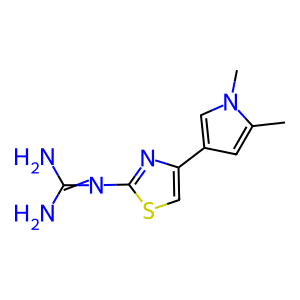

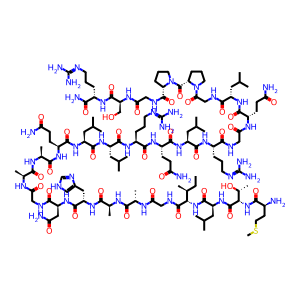

In [68]:
##Can generate the first 10 images in this data set

x = 0
for mol in Chembl:        
    img = Draw.MolToImage(mol)
    ## Display img is much better than img.show as it runs in the vsc console and not on the photos file on the computer 
    display(img)
    x = x + 1 
    if x >= 2:
        break

In [ ]:
writer = Chem.SDWriter("new_sulfur_molecules.sdf")

##for mol in Chembl:
 ##   smile = Chem.MolToSmiles(mol)
 ##   if 'SSS' in smile:
 ##       writer.write(mol)
        

### Should take the first 10 molecules in the chembl set and if they have sulfur in them, write it to a new file
# Check if there are sulfur-containing molecules
sulfur_count = 0

x = 0
for mol in Chembl:        
    smile = Chem.MolToSmiles(mol)
    x = x + 1 
    if x >= 5000:
        break
    if 'S' in smile:
        writer.write(mol)
        sulfur_count += 1


# close the writer
writer.close

if sulfur_count == 0:
    print("No sulfur-containing molecules found.")
else:
    print(f"{sulfur_count} sulfur-containing molecules written to sulfur_molecules.sdf.")


# 5 Seconds = 1000 molecules

len("new_sulfur_molecules.sdf")

## Why is the len 24? Because that's how many letters are in new_sulfur_molecules.sdf

### Displays the 1092 images of what is in the sulfur molecules sdf file.
#Sulfur = Chem.SDMolSupplier("new_sulfur_molecules.sdf")

#for mol in Sulfur:        
 #   img = Draw.MolToImage(mol)
 #   ## Displays what is in the new_sulfur_molecules.sdf  
 #   display(img)

1092 sulfur-containing molecules written to sulfur_molecules.sdf.


24

In [2]:
## Remove charge in the data set/ cleaning the data

def neutralize_atoms(mol):
    pattern = Chem.MolFromSmarts("[+1!h0!$([*]~[-1,-2,-3,-4]),-1!$([*]~[+1,+2,+3,+4])]")
    at_matches = mol.GetSubstructMatches(pattern)
    at_matches_list = [y[0] for y in at_matches]
    if len(at_matches_list) > 0:
        for at_idx in at_matches_list:
            atom = mol.GetAtomWithIdx(at_idx)
            chg = atom.GetFormalCharge()
            hcount = atom.GetTotalNumHs()
            atom.SetFormalCharge(0)
            atom.SetNumExplicitHs(hcount - chg)
            atom.UpdatePropertyCache()
    return mol

In [ ]:
Sulfur = Chem.SDMolSupplier('new_sulfur_molecules.sdf')
# Generate an empty list that we can then append the fingerprint data to with all of the sulfur molecules
fingerprint_list = []
mol_list = []

for mol in Sulfur:
    if mol is None: continue
    mol = neutralize_atoms(mol)
    if len(mol.GetAtoms()) > 250:
        continue
    fpgen = AllChem.GetRDKitFPGenerator()
    fps = fpgen.GetFingerprint(mol)
    fingerprint_list.append(fps)
    mol_list.append(mol)
# The length of this list is the same as the amount of sulfur molecules
print(len(fingerprint_list))

    

1056


In [ ]:

## Now we want to make the data as a fingerprint and compare it's similarity, so that we can get data that isn't similar to other molecules, they should all
## be unqiue
## We need to use DataStructs.TanimotoSimilarity(fps[0],fps[1]) commands as part of the RDkit package

## X is the first 100 terms in the list, y is the rest of the list
x = fingerprint_list[:50]
y = fingerprint_list[50:]

## To calculate tanimoto similarity 
for i, fp_x in enumerate(x):
    for j, fp_y in enumerate(y):
        similarity = DataStructs.TanimotoSimilarity(fp_x, fp_y)
        if similarity < 0.6:  # threshold 
            print(f"Unique pair found with low similarity ({similarity}) between x[{i}] and y[{j}]")



Unique pair found with low similarity (0.4026651216685979) between x[0] and y[0]
Unique pair found with low similarity (0.31332868108862527) between x[0] and y[1]
Unique pair found with low similarity (0.2648221343873518) between x[0] and y[2]
Unique pair found with low similarity (0.5398818316100443) between x[0] and y[3]
Unique pair found with low similarity (0.396168108776267) between x[0] and y[5]
Unique pair found with low similarity (0.28236130867709813) between x[0] and y[6]
Unique pair found with low similarity (0.30742539902845245) between x[0] and y[7]
Unique pair found with low similarity (0.5398683247988295) between x[0] and y[8]
Unique pair found with low similarity (0.36820652173913043) between x[0] and y[10]
Unique pair found with low similarity (0.5098612125639153) between x[0] and y[11]
Unique pair found with low similarity (0.4029943855271366) between x[0] and y[12]
Unique pair found with low similarity (0.56672760511883) between x[0] and y[13]
Unique pair found with 

In [73]:
## Now we want to make the data as a fingerprint and compare it's similarity, so that we can get data that isn't similar to other molecules, they should all
## be unqiue
## We need to use DataStructs.TanimotoSimilarity(fps[0],fps[1]) commands as part of the RDkit package

## X is the first 50 terms in the list, y is the rest of the list
x = fingerprint_list[:50]
y = fingerprint_list[50:]

## To calculate tanimoto similarity  
unique_similarities = []

# Loop over x and y to calculate Tanimoto similarity
for i, fp_x in enumerate(x):
    for j, fp_y in enumerate(y):
        similarity = DataStructs.TanimotoSimilarity(fp_x, fp_y)
        if similarity < 0.1:  # Adjust threshold as needed for "unique" criteria
            unique_similarities.append(similarity)

# Output the number of pairs that are unique
print("Number of unique pairs:", len(unique_similarities))

Number of unique pairs: 483


In [12]:

## Take out the pairs and create a list with those positions. 
# Split into two parts: X is the first 100 fingerprints, Y is the rest of the list
## X is just the reference, X is fine, but Y should  be everything else, find the values of Y not the  values of X

mol_X = mol_list[:50]
mol_Y = mol_list[50:] 
x = fingerprint_list[:50]
y = fingerprint_list[50:]

# Make empty list which we will add uniques too 
unique_positions = []

# Loop over every fingerprint in X
for i, fp_y in enumerate(y):
    # Flag to track if the molecule in Y has a close match in X
    #is_unique = False
    sum_diff = 0
    
    # Compare with every fingerprint in X
    for fp_x in x:
        similarity = DataStructs.TanimotoSimilarity(fp_x, fp_y)
        sum_diff += similarity
        
        '''
        # If similarity higher than 0.something , it's not unique. 0 is different and unique
        if similarity <= 0.2:
            is_unique = True
            break
        '''
    
    avg_sim = sum_diff / len(mol_X)
    
    if avg_sim <= 0.2:
    # If no close matches were found in Y, add to unique_positions
        unique_positions.append(i)

# Output the unique positions in Y
print("Unique positions in Y:", unique_positions)
print("Number of unique molecules in Y:", len(unique_positions))




Unique positions in Y: [31, 32, 34, 52, 70, 78, 81, 92, 98, 100, 102, 109, 113, 131, 147, 173, 194, 232, 266, 303, 308, 364, 417, 428, 474, 482, 484, 490, 493, 549, 550, 551, 552, 676, 687, 717, 721, 745, 757, 763, 772, 782, 785, 795, 799, 800, 802, 805, 806, 808, 820, 823, 830, 835, 839, 840, 843, 860, 866, 867, 878, 887, 896, 900, 922, 938, 957, 959, 960, 972, 991, 992, 996, 1005]
Number of unique molecules in Y: 74


In [13]:
sampled = [x for x in mol_X]

for i in unique_positions:
    sampled.append(mol_Y[i])

len(sampled)



124

In [14]:

##Makes the molecules in sample become 3d instead of 2d (takes 92mins)
sampled_3d = []
for mol in sampled:
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    sampled_3d.append(mol)



[18:20:15] UFFTYPER: Unrecognized charge state for atom: 0
[18:20:15] UFFTYPER: Unrecognized charge state for atom: 0
[18:20:17] UFFTYPER: Unrecognized charge state for atom: 0


In [15]:
## Now, create an sdf file for all the sampled data, each individual molecule should be turned into it's own sdf file 
## First we need to loop through each molecule in the sampled list
for idx, mol in enumerate(sampled_3d):
    # Begin the creation of an SDF writer, idx + 1 allows the molecules to have different names in their files
    writer = Chem.SDWriter(f'molecule_{idx + 1}.sdf')
    
    # Check if the molecule is valid, although we have previously removed "none" molecules, this is a good final check
    if mol is not None:
        # Write the molecule to the it's own SDF file
        writer.write(mol)  
    # Close the writer to finalize the file
    writer.close()

print((idx + 1),"SDF files generated")



## What do they look like? 



124 SDF files generated


In [69]:
'''# Specify the range of SDF files to display (e.g., 1 to 123) 
# THis is a shitty way of viewing them and I think the way below is much better, 
start_idx = 5
end_idx = start_idx + 1

# List to store molecules for batch display
molecules = []

# Loop through the specified range of files
for idx in range(start_idx, end_idx + 1):
    filename = f'molecule_{idx}.sdf'

        # Check if the file exists
    if os.path.exists(filename):
        # Read the molecule from the SDF file
        suppl = Chem.SDMolSupplier(filename)
         # Get the first molecule from the file
        mol = suppl[0] 
        # Append the valid molecule to the list
        if mol:
            molecules.append(mol)
    else:
        print(f"File {filename} does not exist.")

# Display molecules in a grid 
if molecules:
    img = Draw.MolsToGridImage(molecules, molsPerRow=2, subImgSize=(1000, 1000))
    display(img)
else:
    print("No molecules found to display.")

'''

'# Specify the range of SDF files to display (e.g., 1 to 123) \n# THis is a shitty way of viewing them and I think the way below is much better, \nstart_idx = 5\nend_idx = start_idx + 1\n\n# List to store molecules for batch display\nmolecules = []\n\n# Loop through the specified range of files\nfor idx in range(start_idx, end_idx + 1):\n    filename = f\'molecule_{idx}.sdf\'\n\n        # Check if the file exists\n    if os.path.exists(filename):\n        # Read the molecule from the SDF file\n        suppl = Chem.SDMolSupplier(filename)\n         # Get the first molecule from the file\n        mol = suppl[0] \n        # Append the valid molecule to the list\n        if mol:\n            molecules.append(mol)\n    else:\n        print(f"File {filename} does not exist.")\n\n# Display molecules in a grid \nif molecules:\n    img = Draw.MolsToGridImage(molecules, molsPerRow=2, subImgSize=(1000, 1000))\n    display(img)\nelse:\n    print("No molecules found to display.")\n\n'

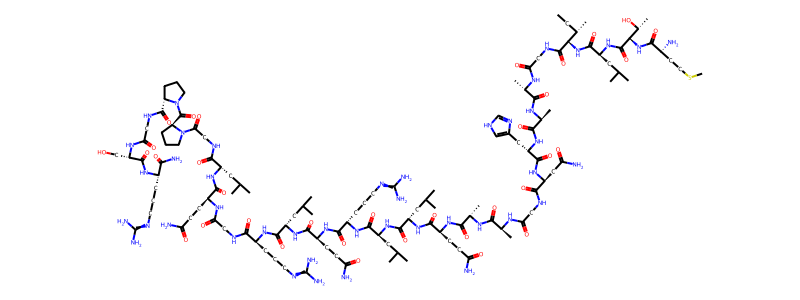

Above is molecule 1


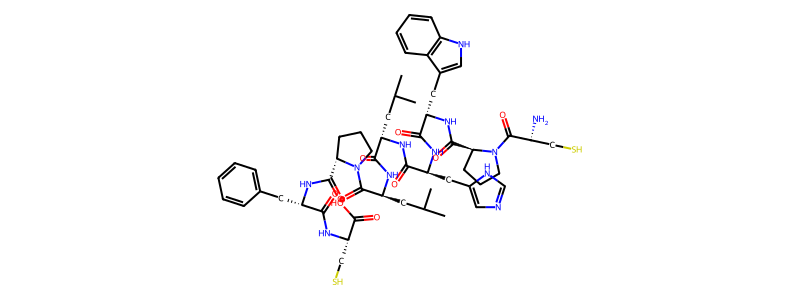

Above is molecule 2


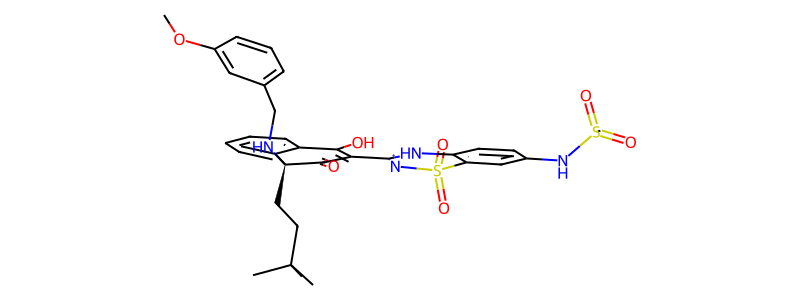

Above is molecule 3


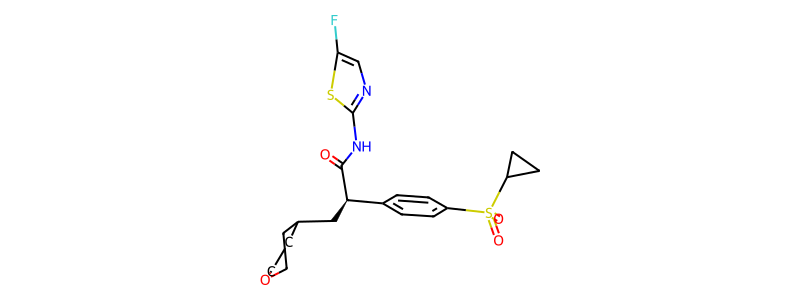

Above is molecule 4


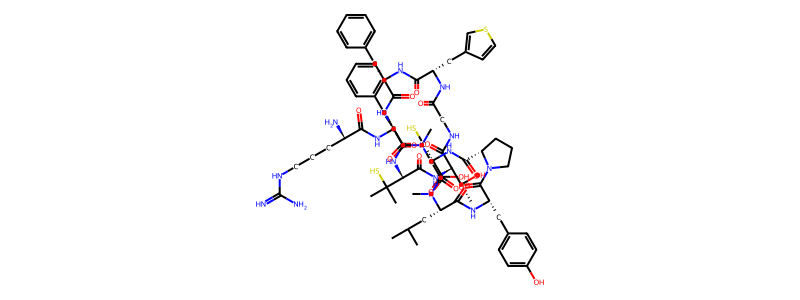

Above is molecule 5


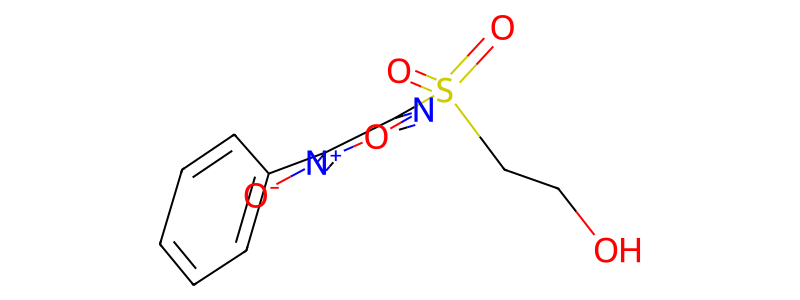

Above is molecule 6


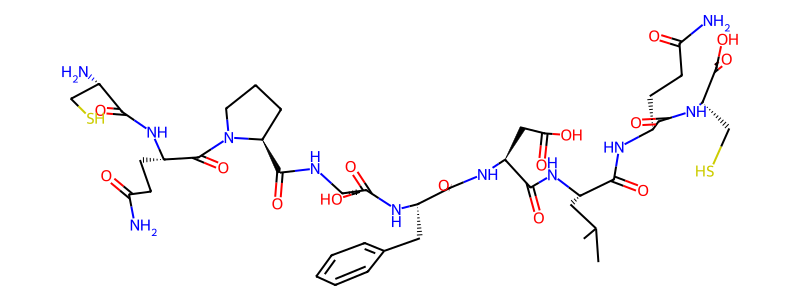

Above is molecule 7


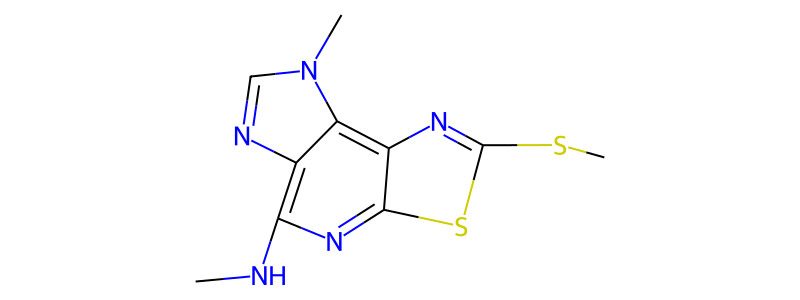

Above is molecule 8


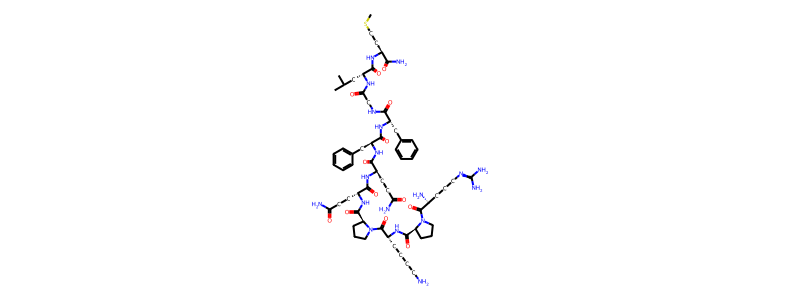

Above is molecule 9


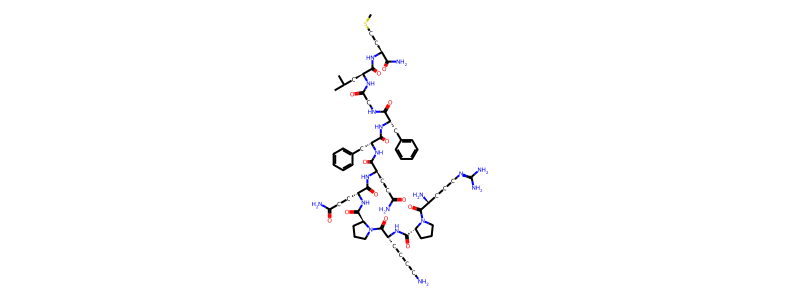

Above is molecule 10


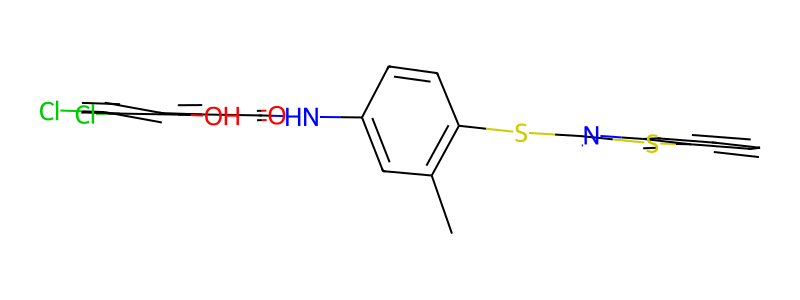

Above is molecule 11


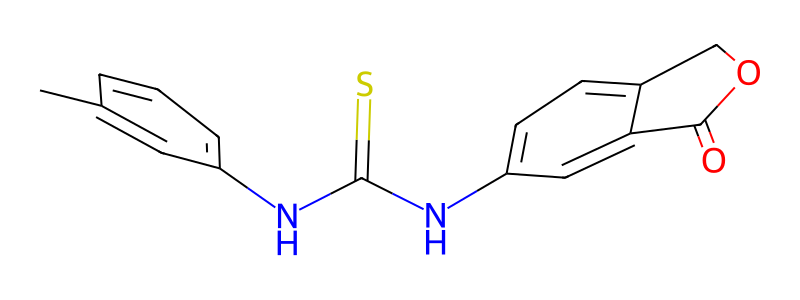

Above is molecule 12


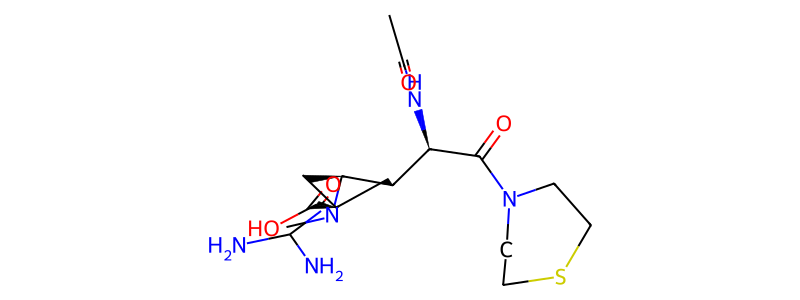

Above is molecule 13


[19:08:08] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 61 ignored


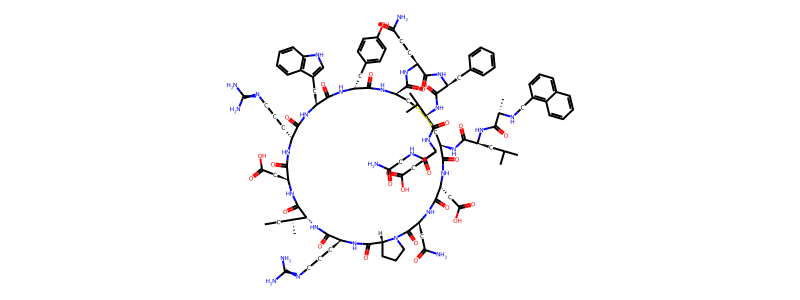

Above is molecule 14


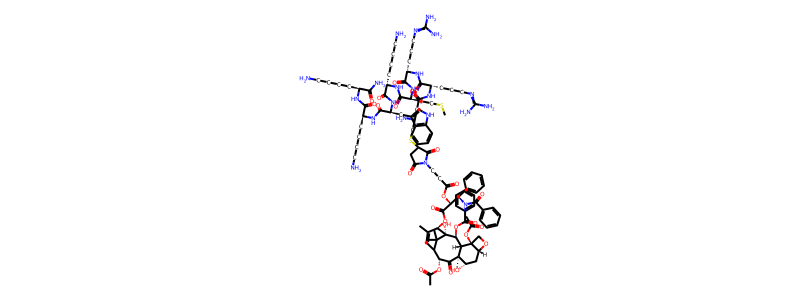

Above is molecule 15


[19:08:08] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 52 ignored


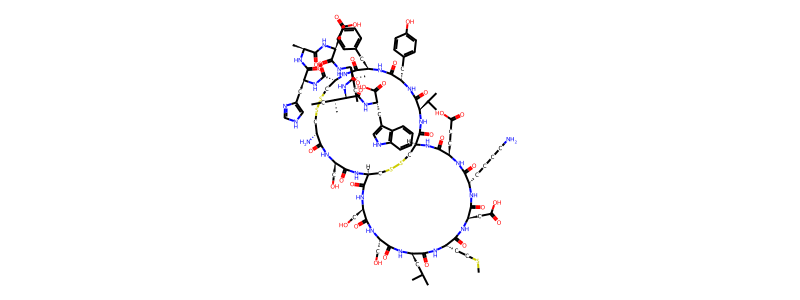

Above is molecule 16


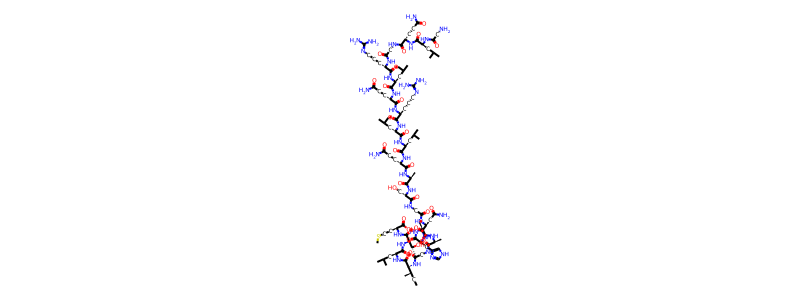

Above is molecule 17


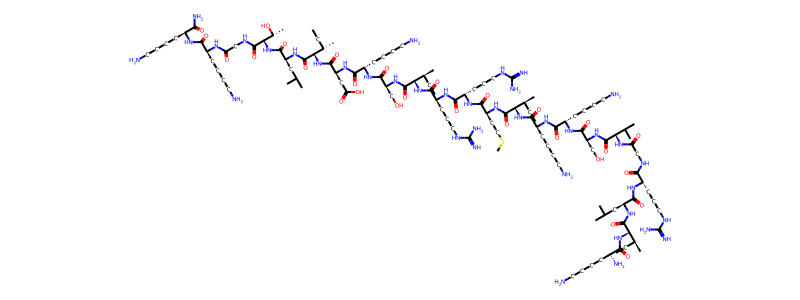

Above is molecule 18


[19:08:08] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 71 ignored


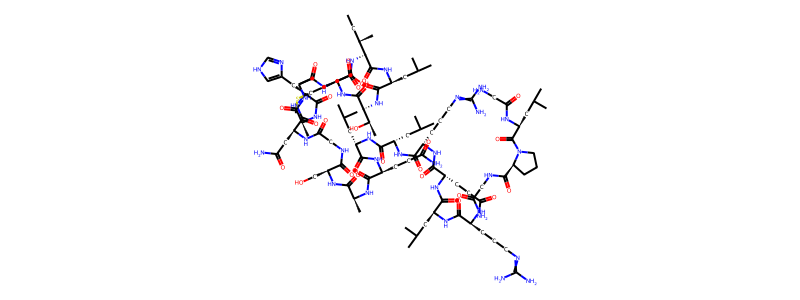

Above is molecule 19


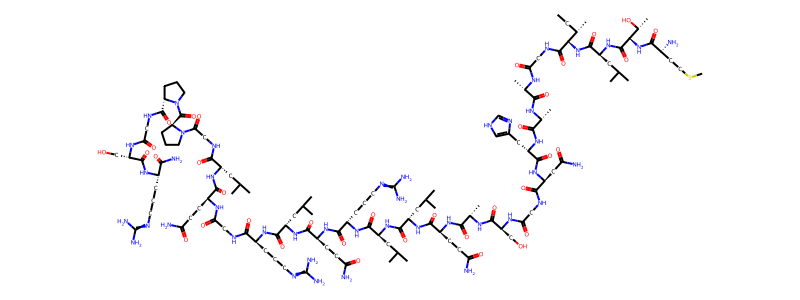

Above is molecule 20


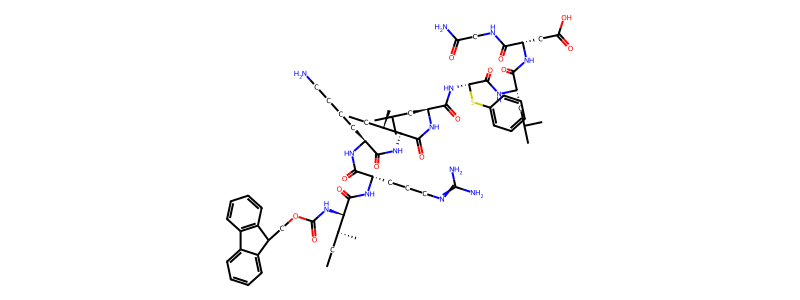

Above is molecule 21


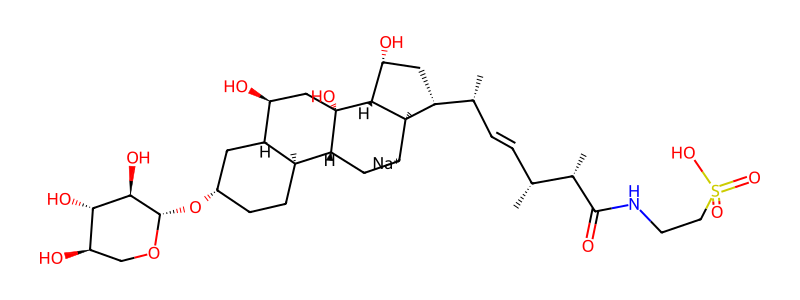

Above is molecule 22


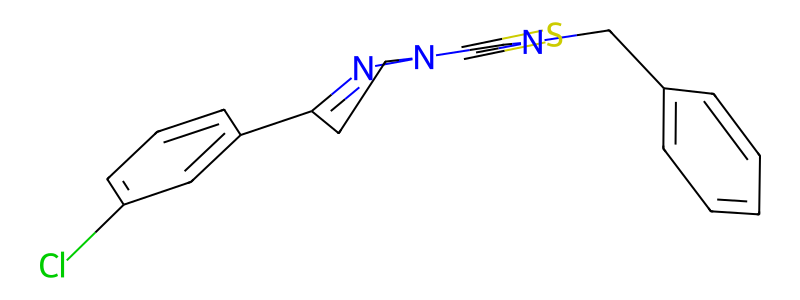

Above is molecule 23


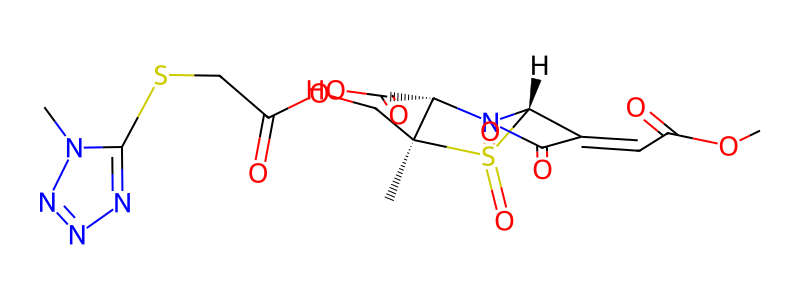

Above is molecule 24


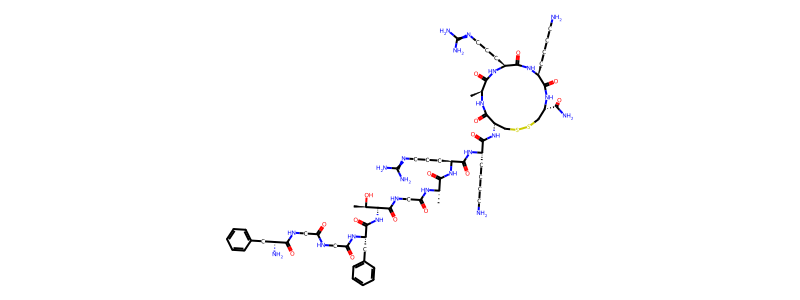

Above is molecule 25


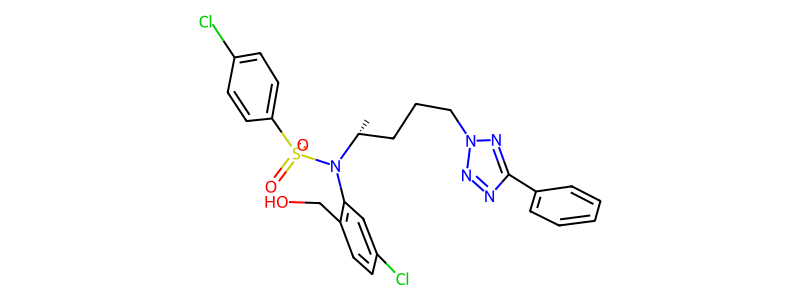

Above is molecule 26


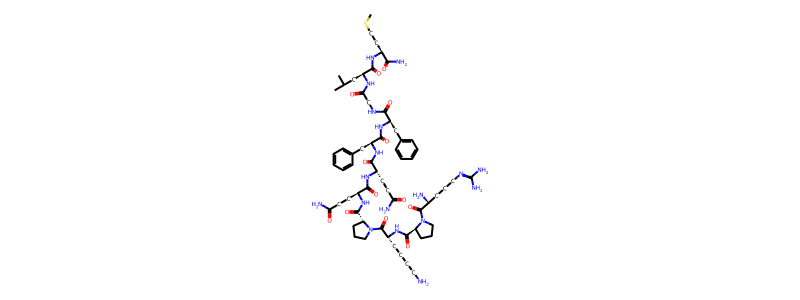

Above is molecule 27


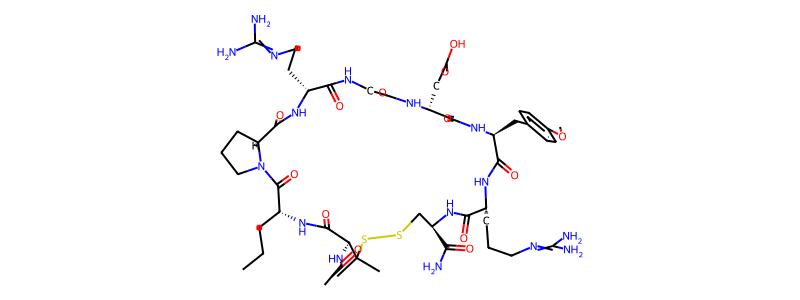

Above is molecule 28


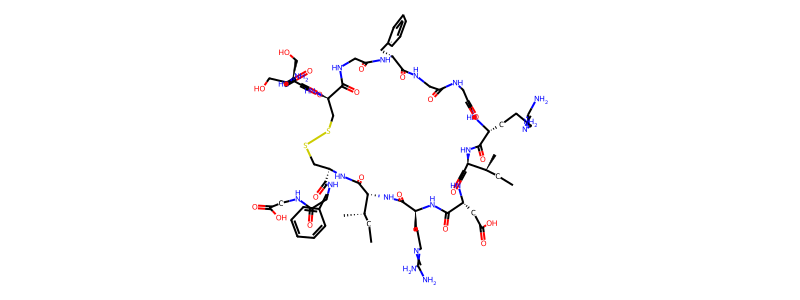

Above is molecule 29


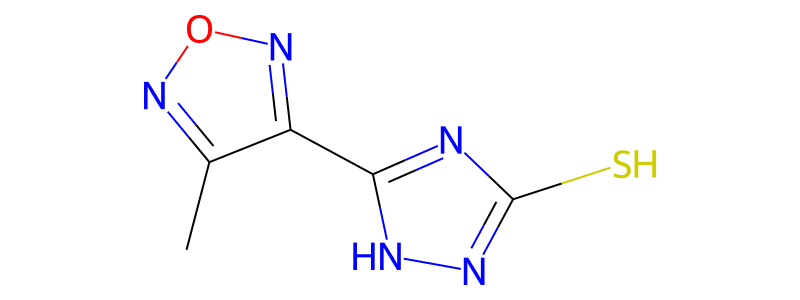

Above is molecule 30


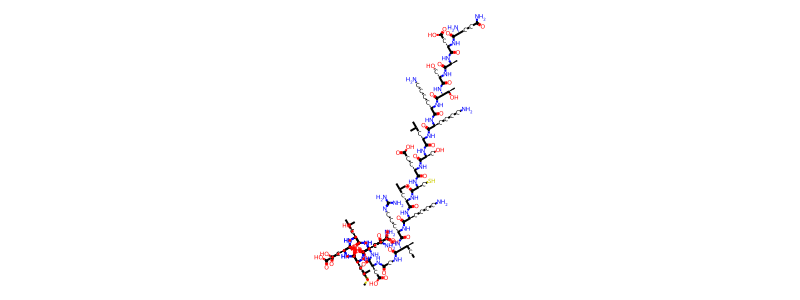

Above is molecule 31


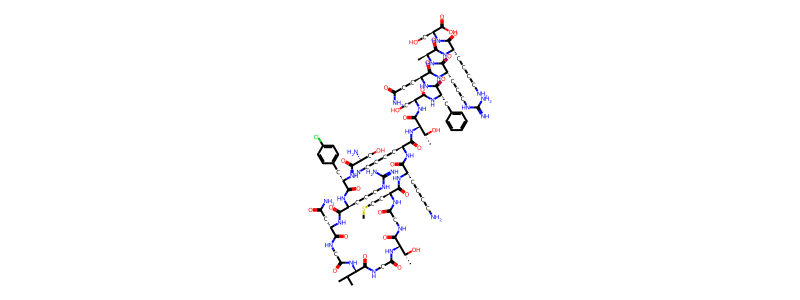

Above is molecule 32


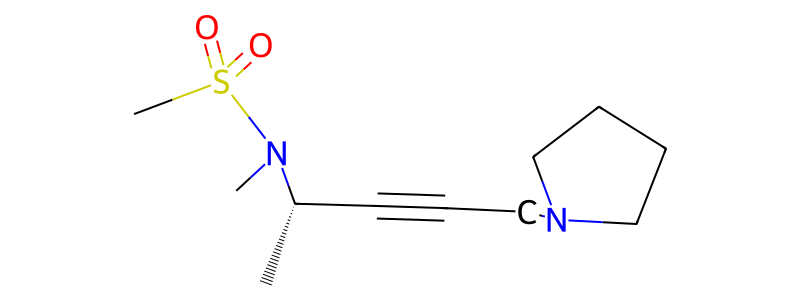

Above is molecule 33


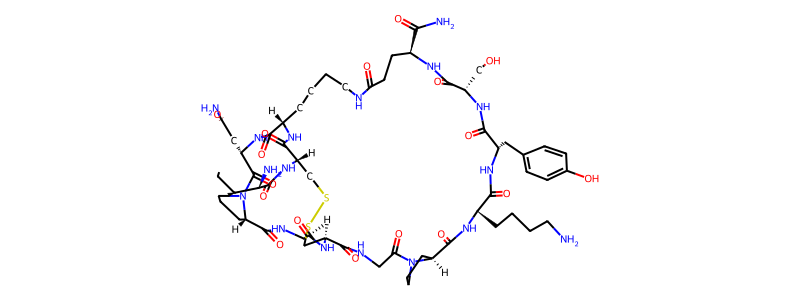

Above is molecule 34


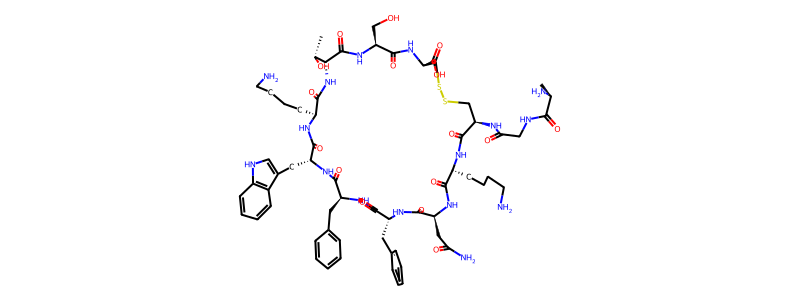

Above is molecule 35


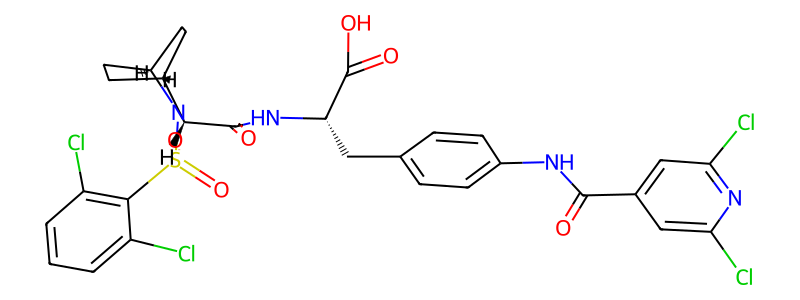

Above is molecule 36


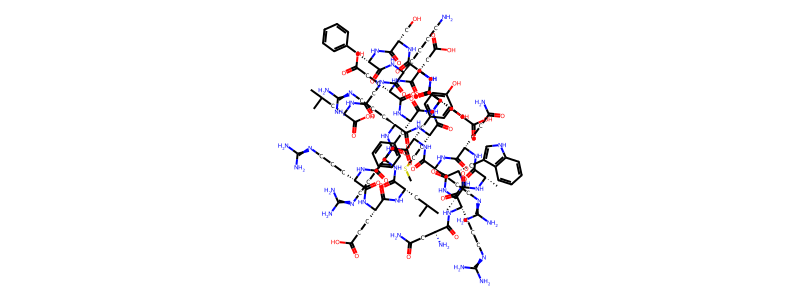

Above is molecule 37


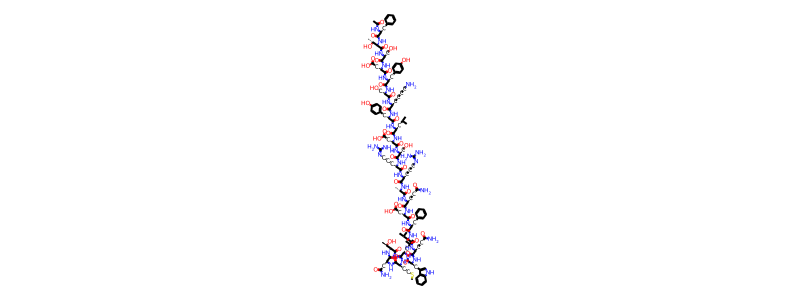

Above is molecule 38


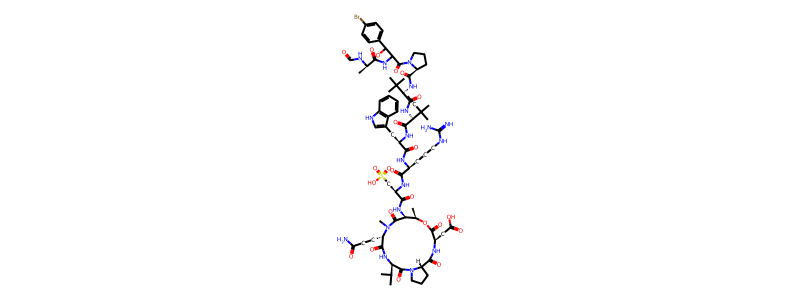

Above is molecule 39


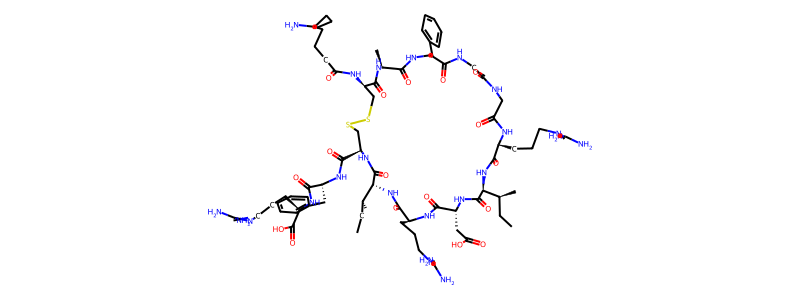

Above is molecule 40


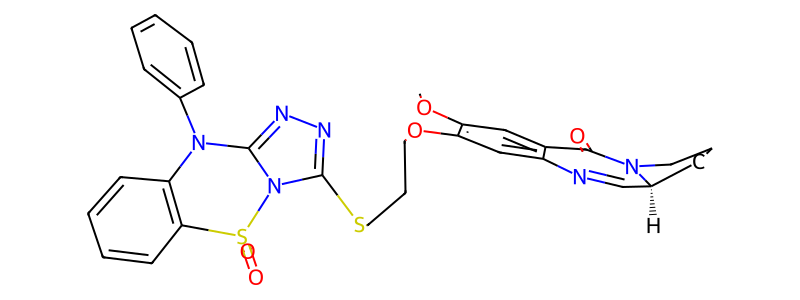

Above is molecule 41


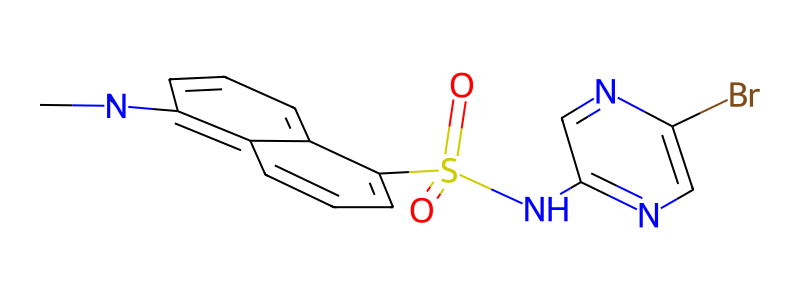

Above is molecule 42


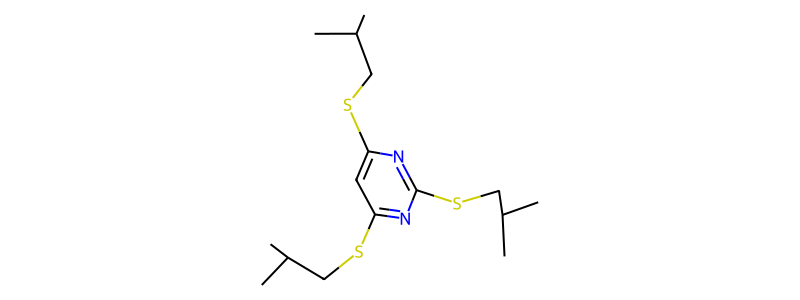

Above is molecule 43


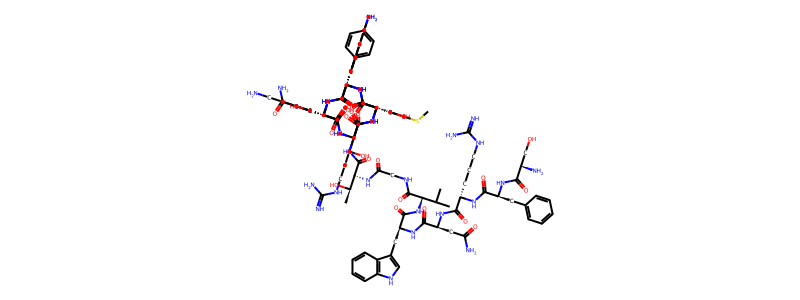

Above is molecule 44


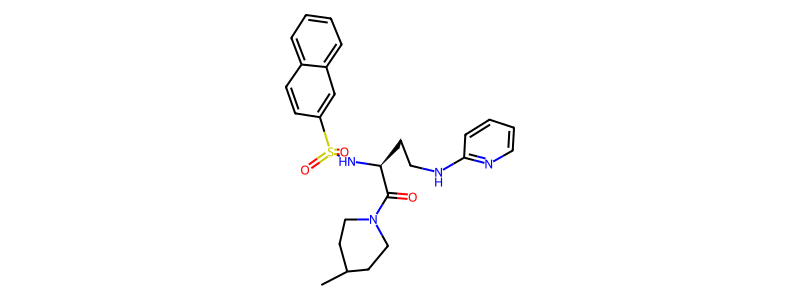

Above is molecule 45


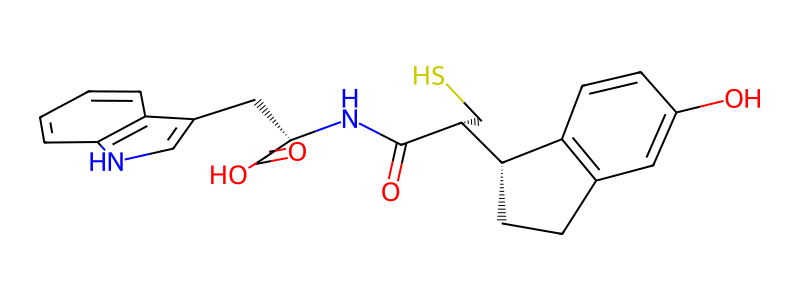

Above is molecule 46


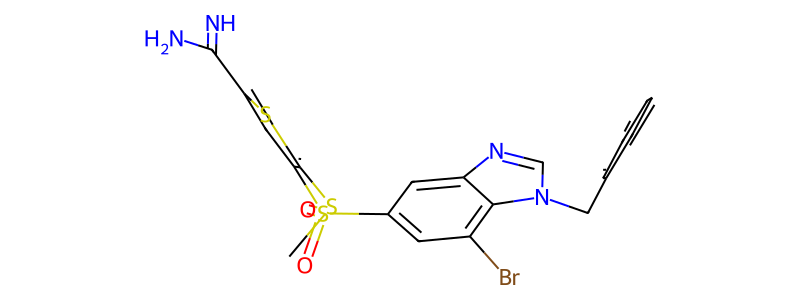

Above is molecule 47


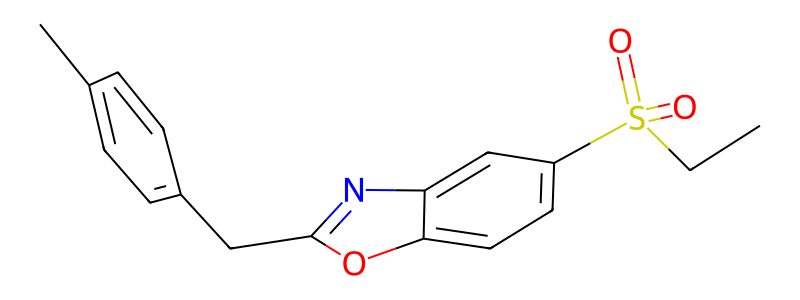

Above is molecule 48


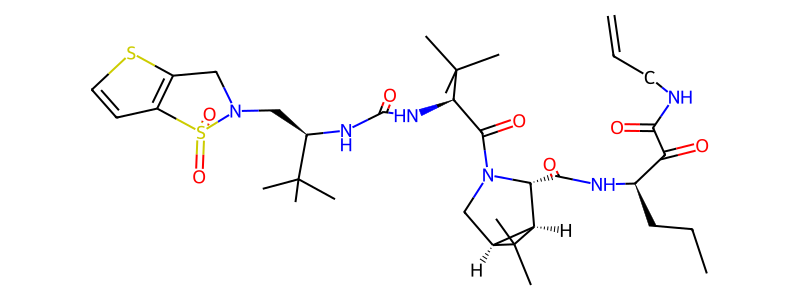

Above is molecule 49


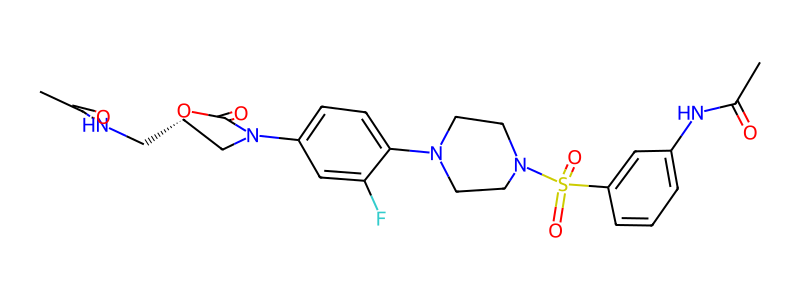

Above is molecule 50


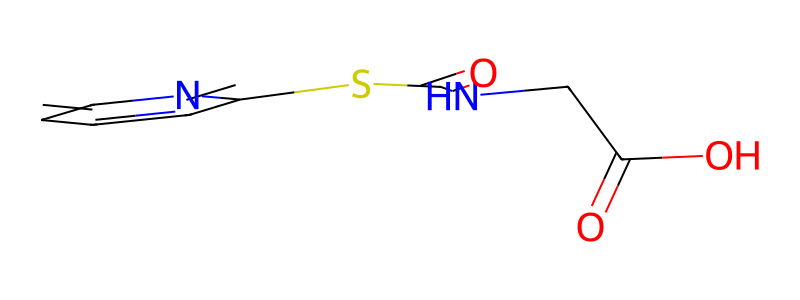

Above is molecule 51


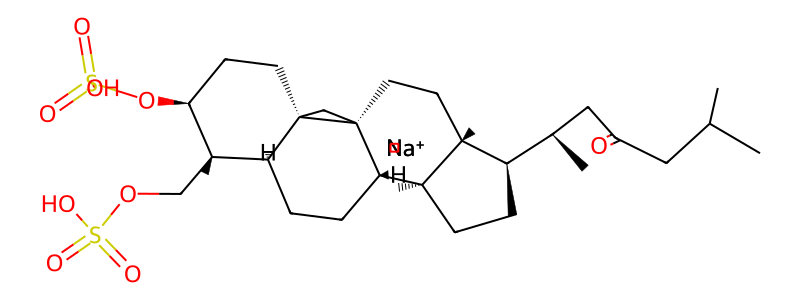

Above is molecule 52


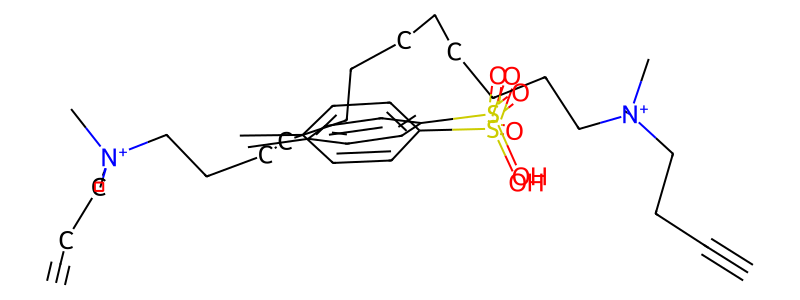

Above is molecule 53


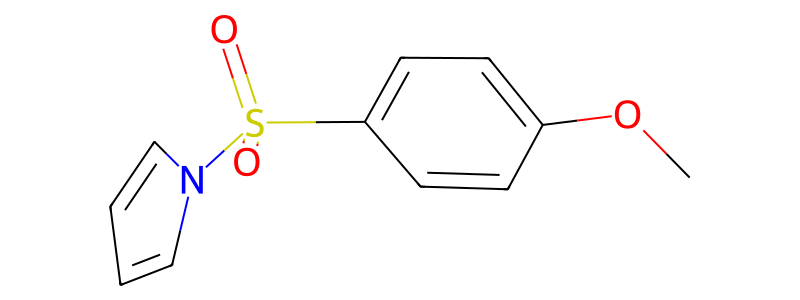

Above is molecule 54


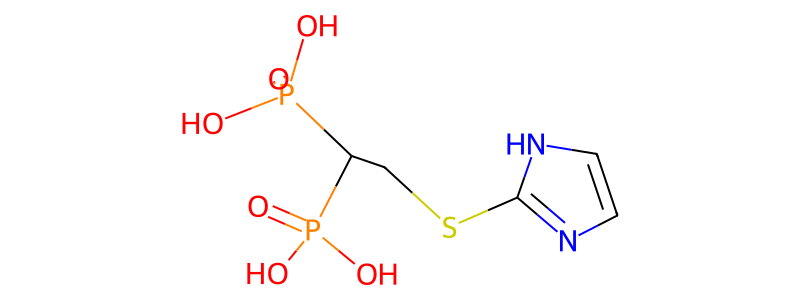

Above is molecule 55


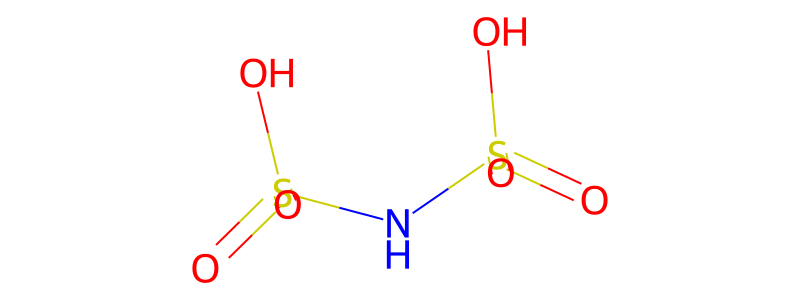

Above is molecule 56


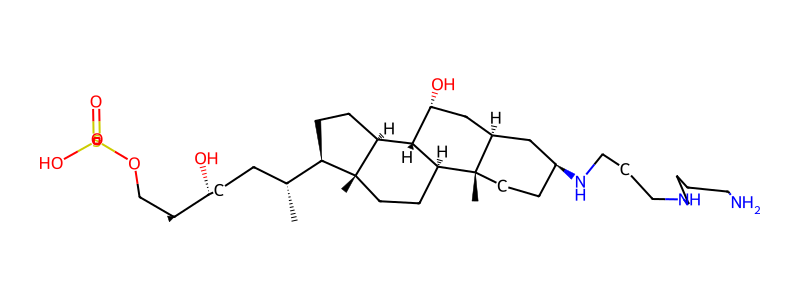

Above is molecule 57


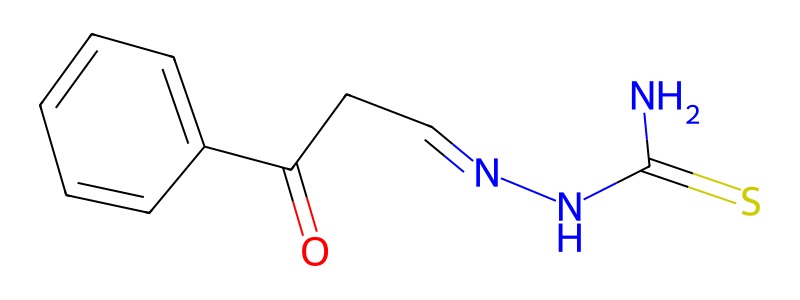

Above is molecule 58


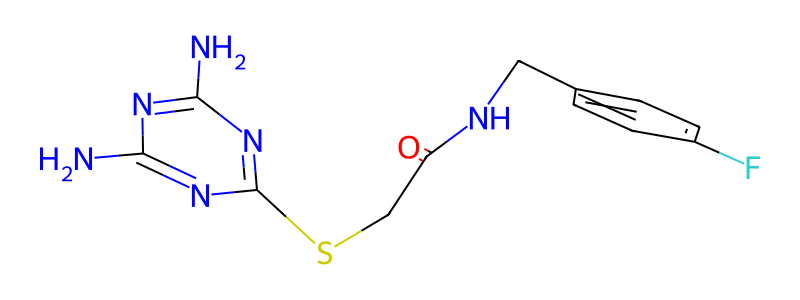

Above is molecule 59


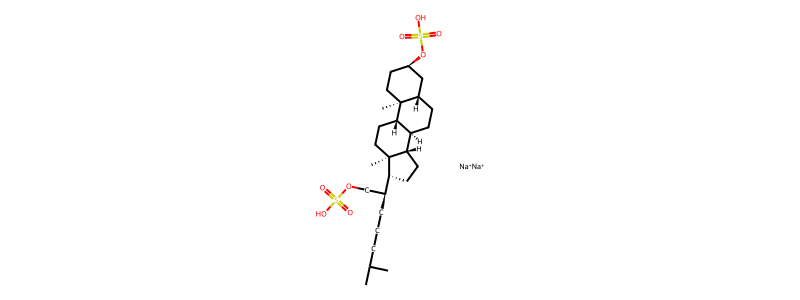

Above is molecule 60


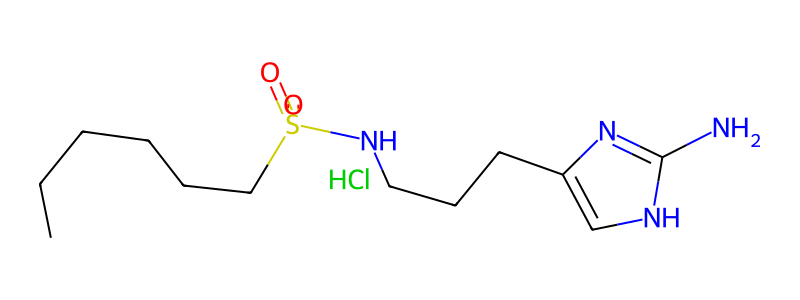

Above is molecule 61


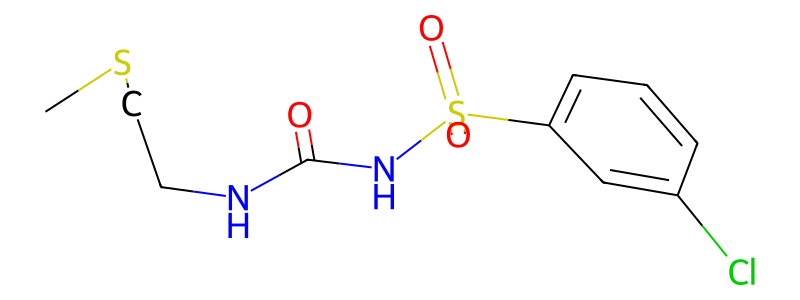

Above is molecule 62


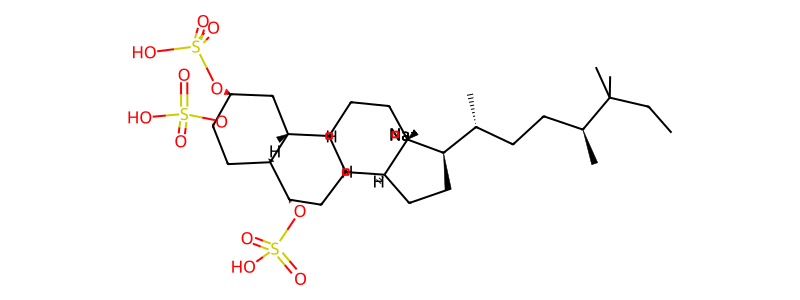

Above is molecule 63


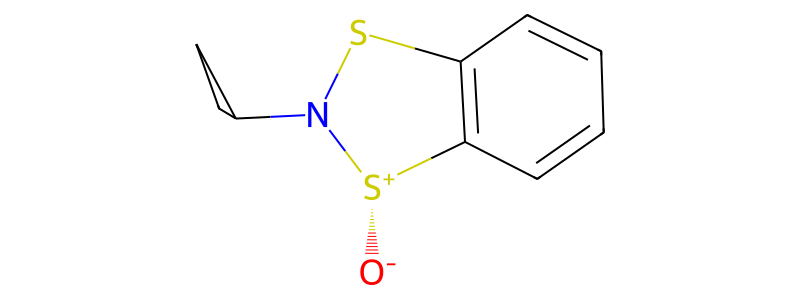

Above is molecule 64


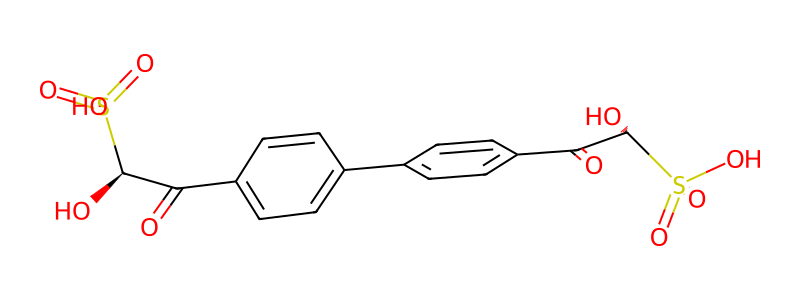

Above is molecule 65


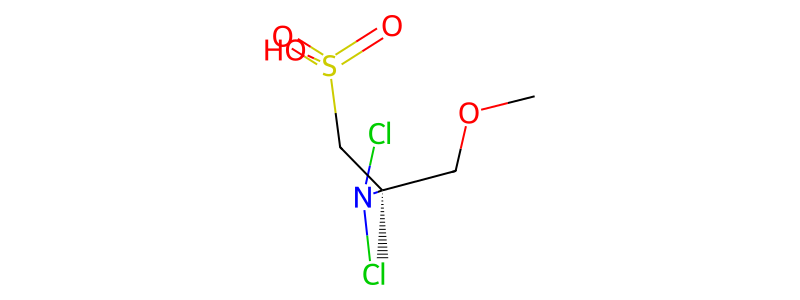

Above is molecule 66


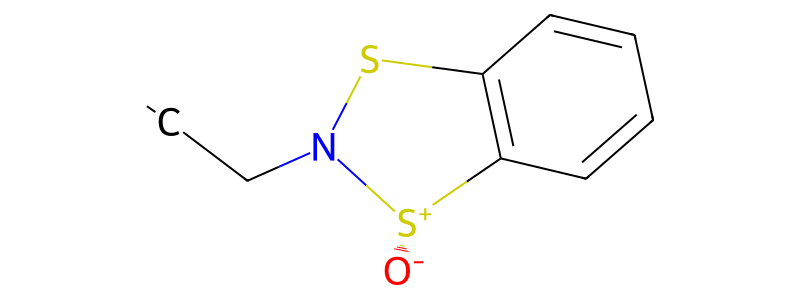

Above is molecule 67


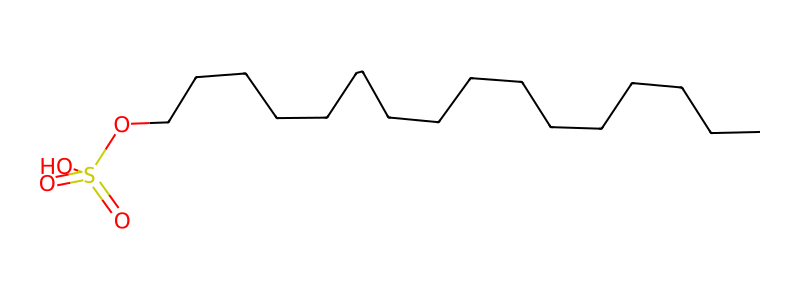

Above is molecule 68


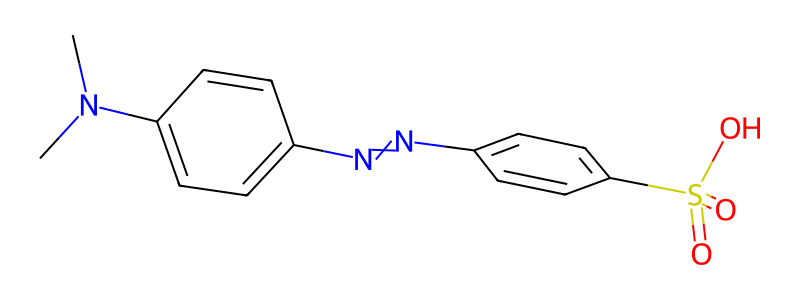

Above is molecule 69


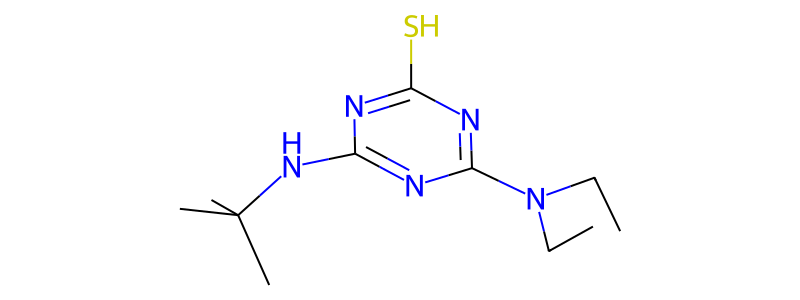

Above is molecule 70


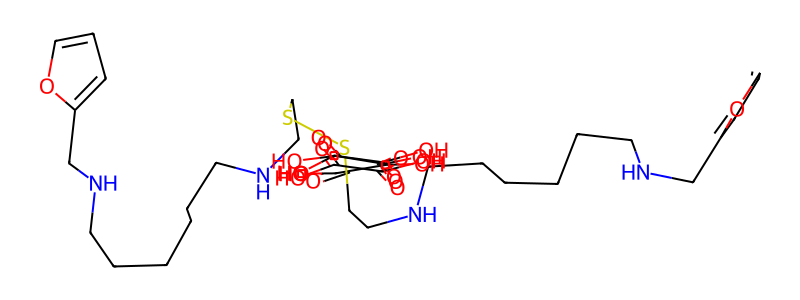

Above is molecule 71


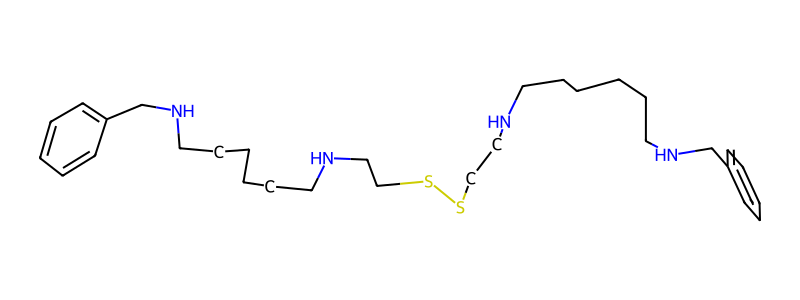

Above is molecule 72


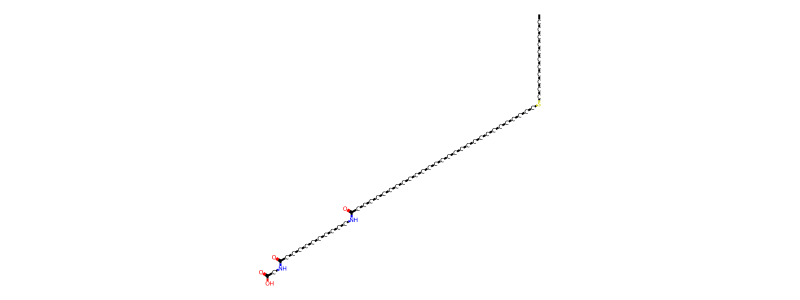

Above is molecule 73


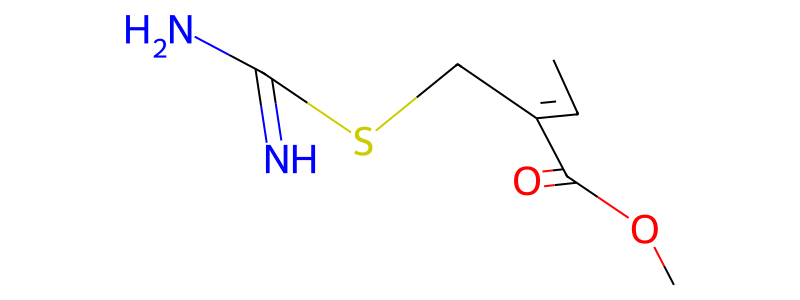

Above is molecule 74


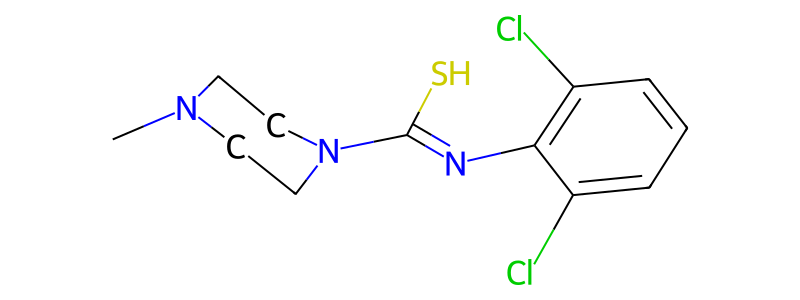

Above is molecule 75


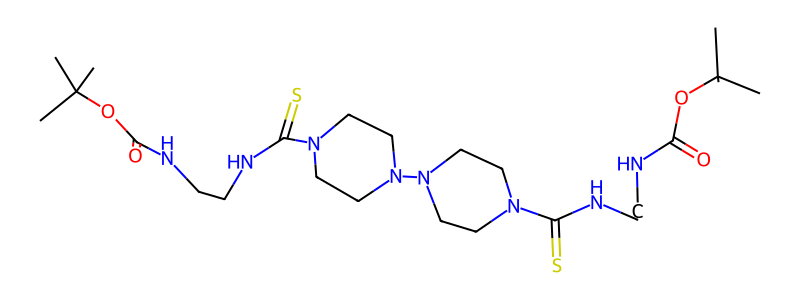

Above is molecule 76


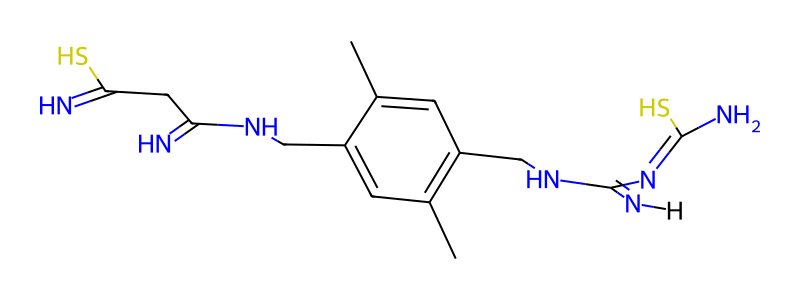

Above is molecule 77


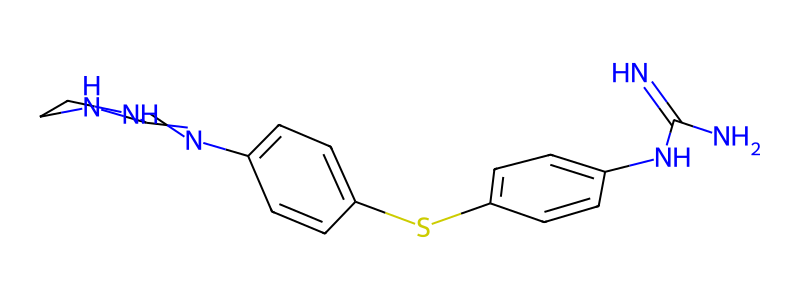

Above is molecule 78


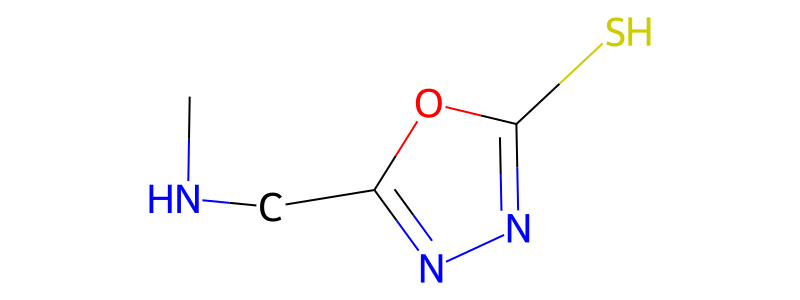

Above is molecule 79


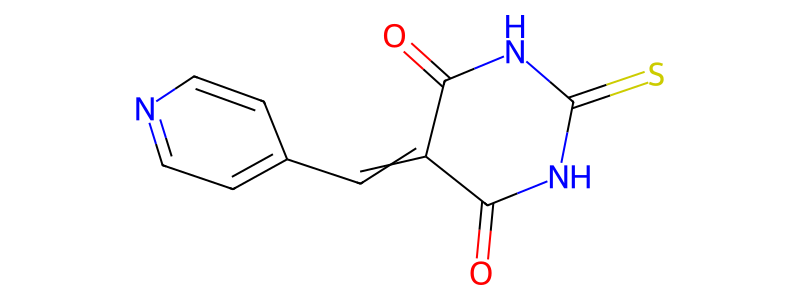

Above is molecule 80


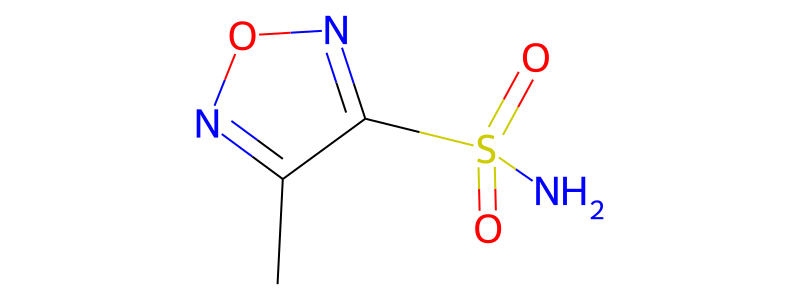

Above is molecule 81


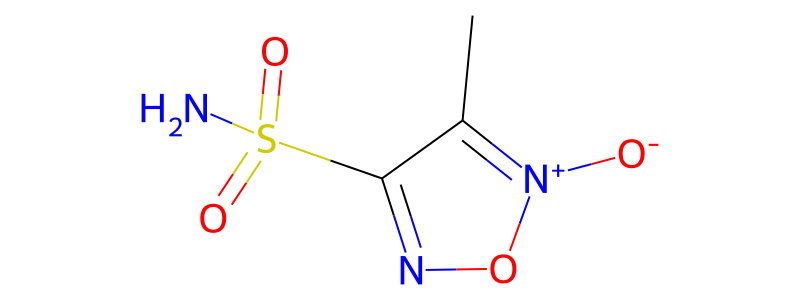

Above is molecule 82


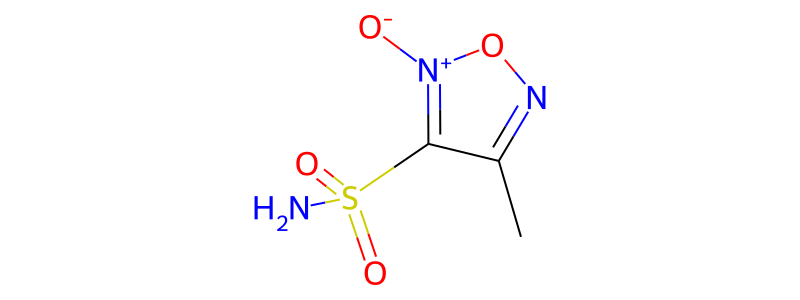

Above is molecule 83


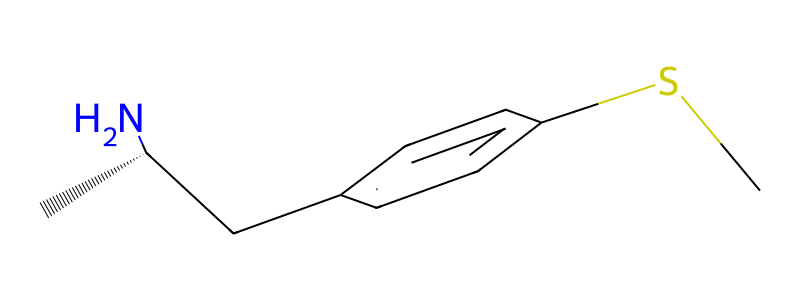

Above is molecule 84


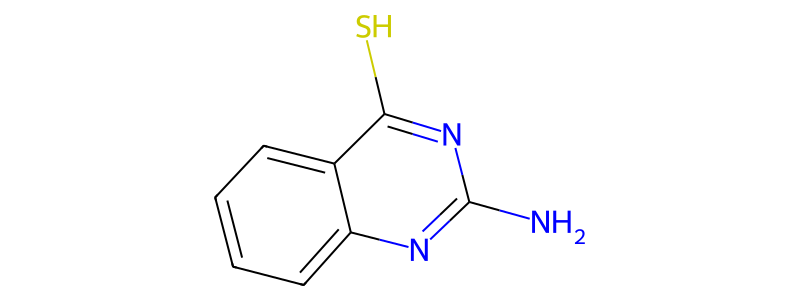

Above is molecule 85


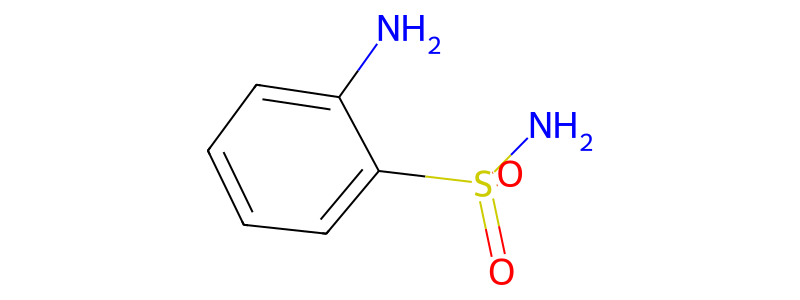

Above is molecule 86


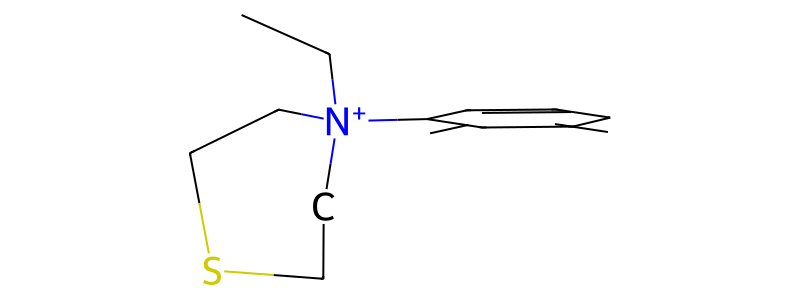

Above is molecule 87


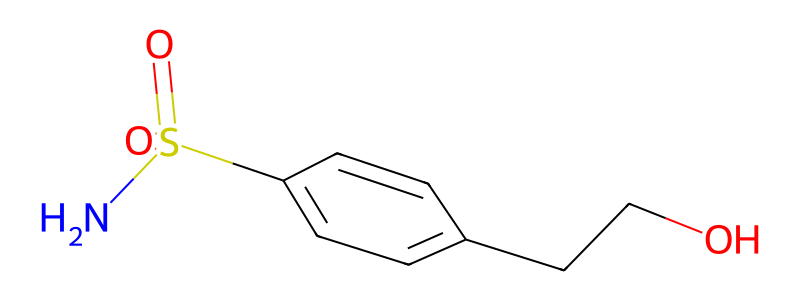

Above is molecule 88


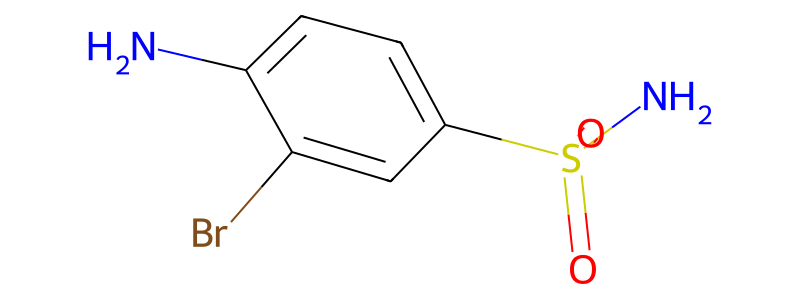

Above is molecule 89


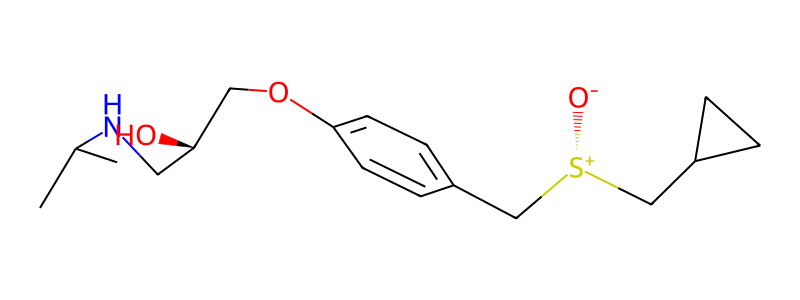

Above is molecule 90


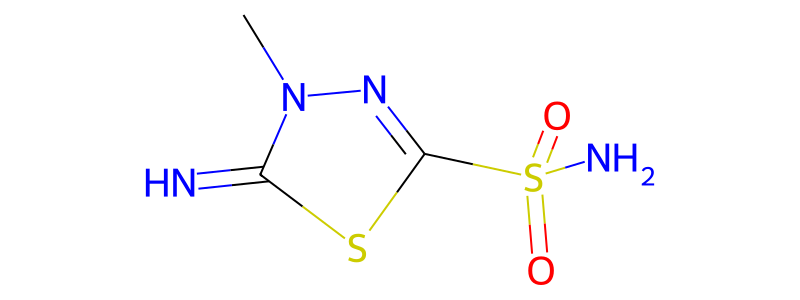

Above is molecule 91


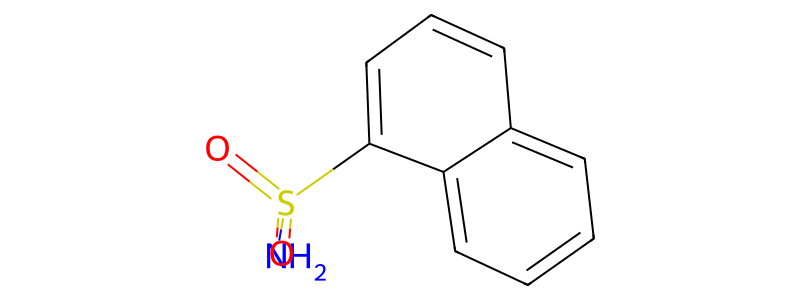

Above is molecule 92


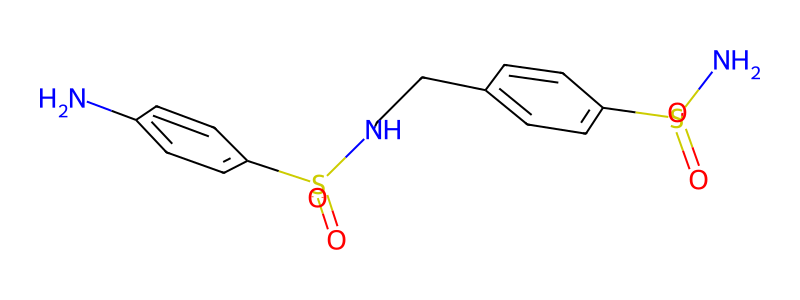

Above is molecule 93


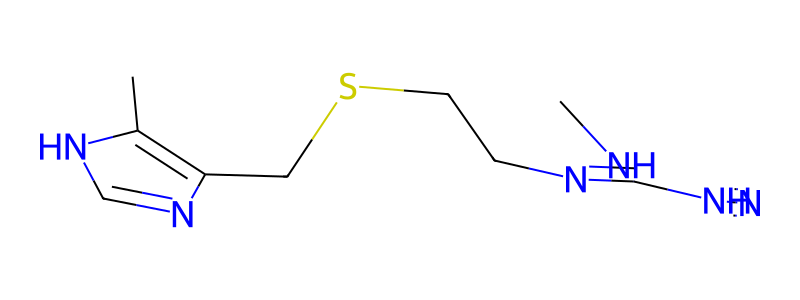

Above is molecule 94


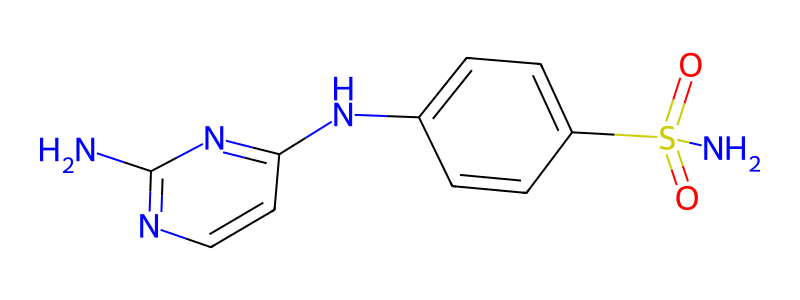

Above is molecule 95


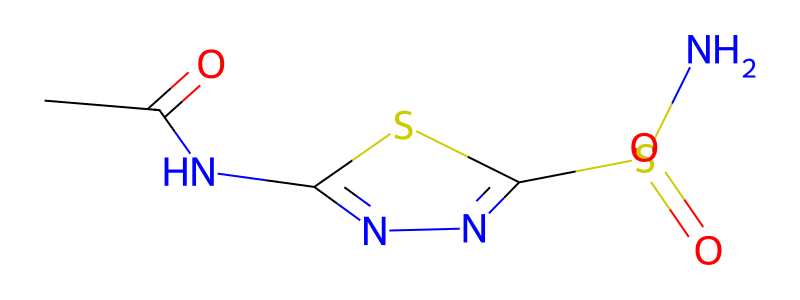

Above is molecule 96


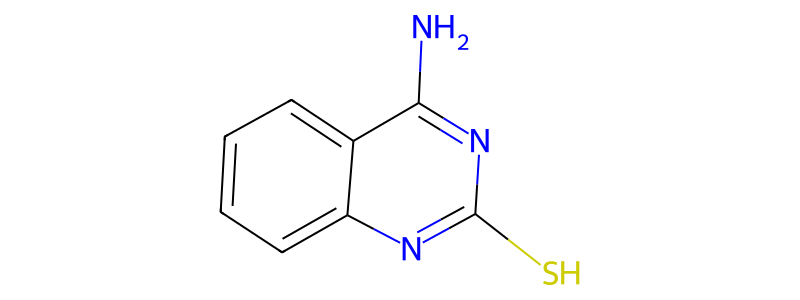

Above is molecule 97


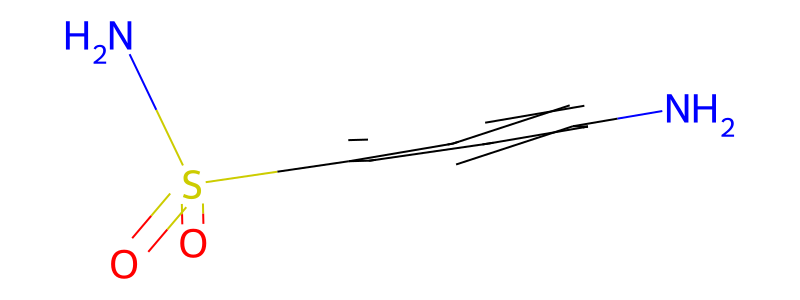

Above is molecule 98


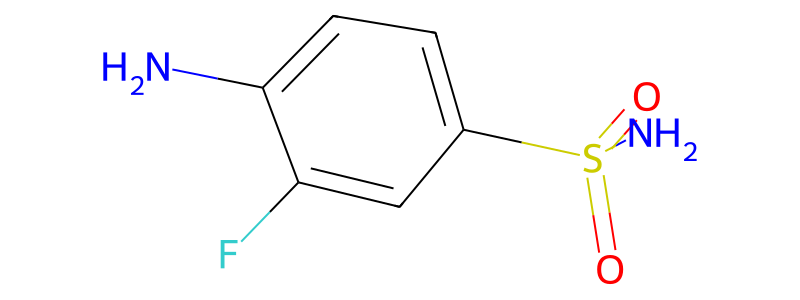

Above is molecule 99


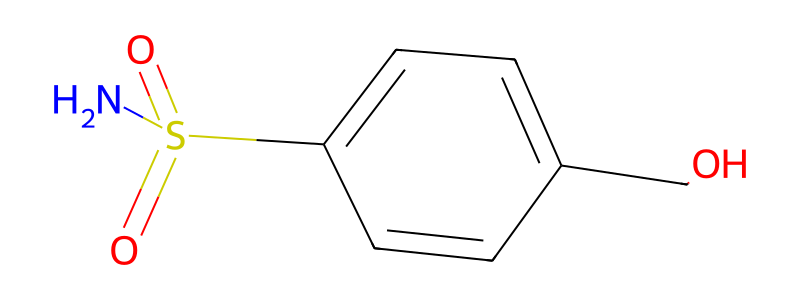

Above is molecule 100


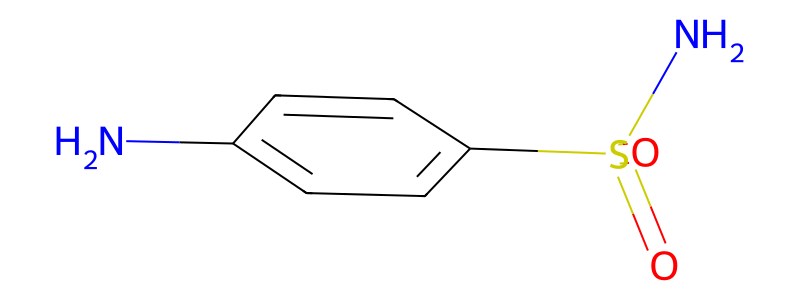

Above is molecule 101


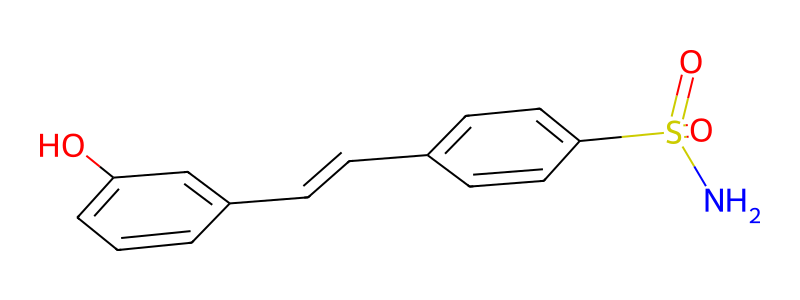

Above is molecule 102


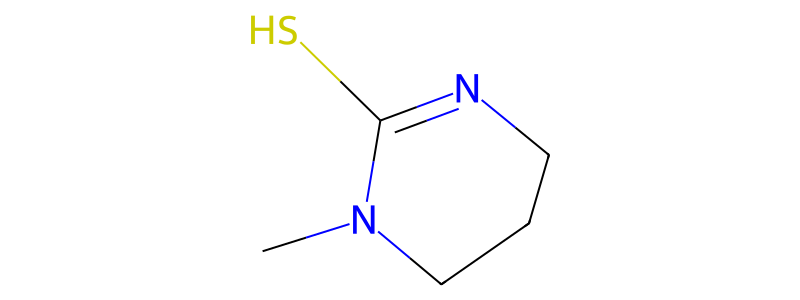

Above is molecule 103


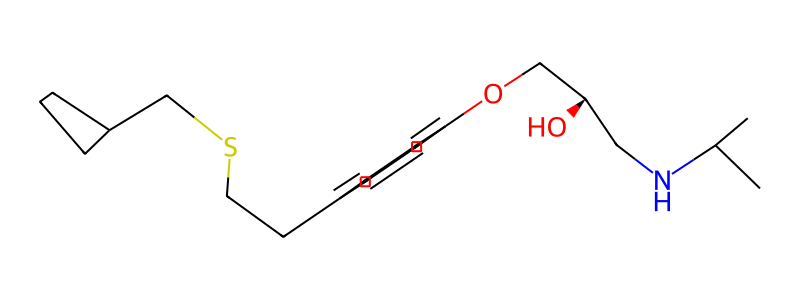

Above is molecule 104


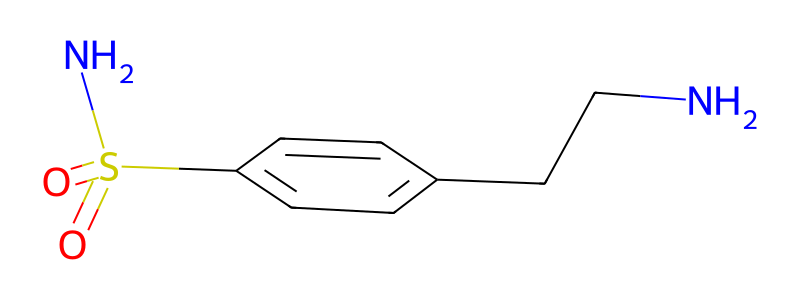

Above is molecule 105


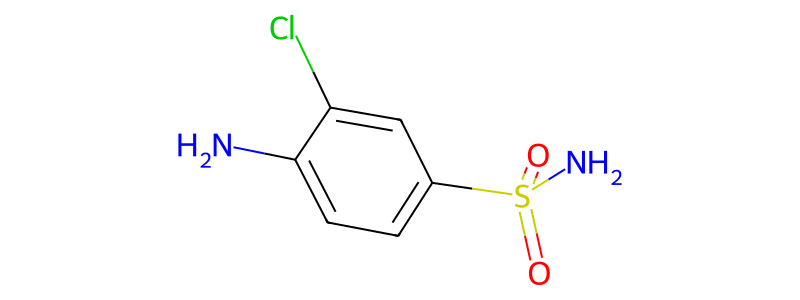

Above is molecule 106


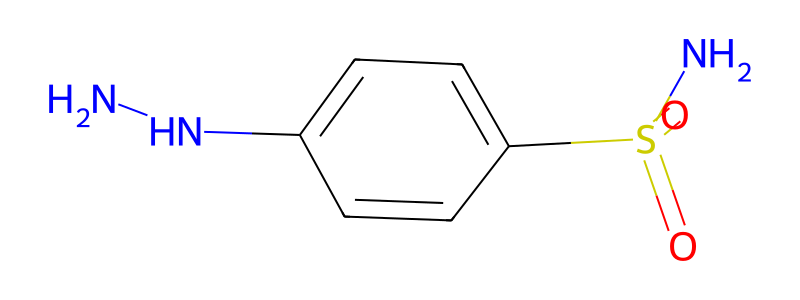

Above is molecule 107


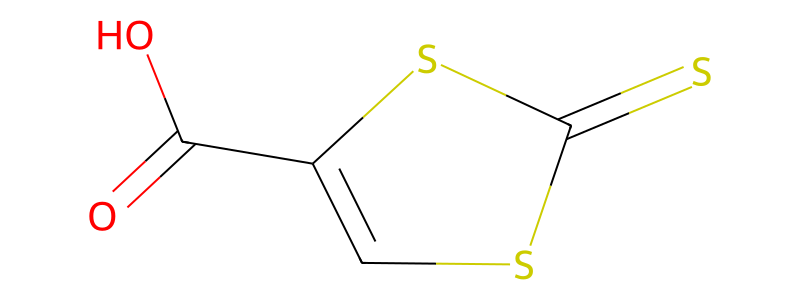

Above is molecule 108


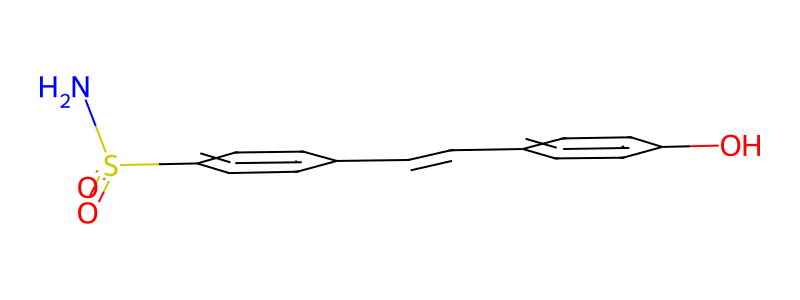

Above is molecule 109


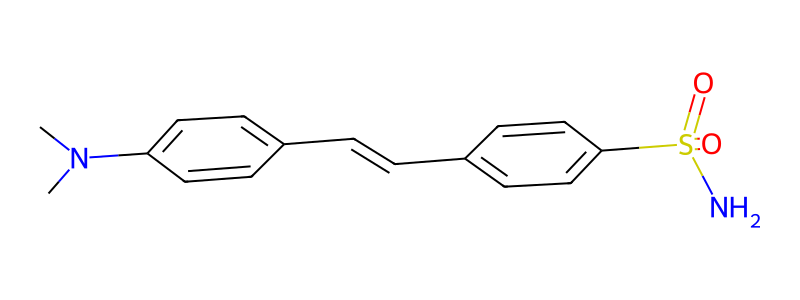

Above is molecule 110


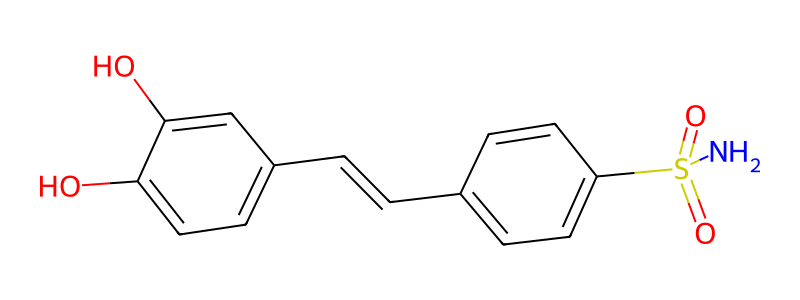

Above is molecule 111


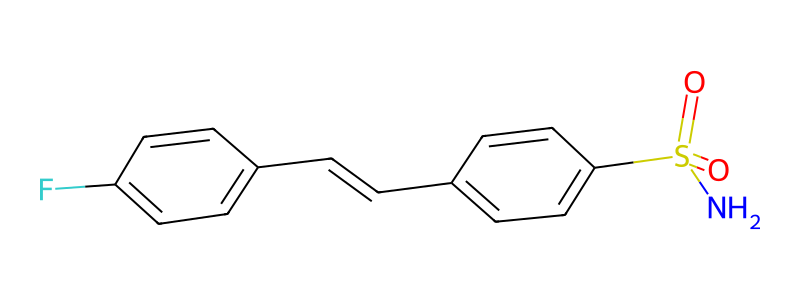

Above is molecule 112


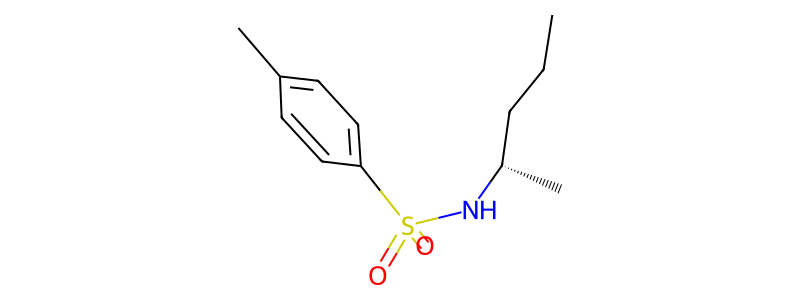

Above is molecule 113


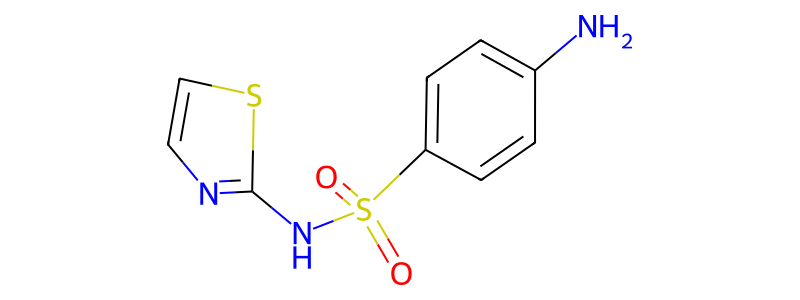

Above is molecule 114


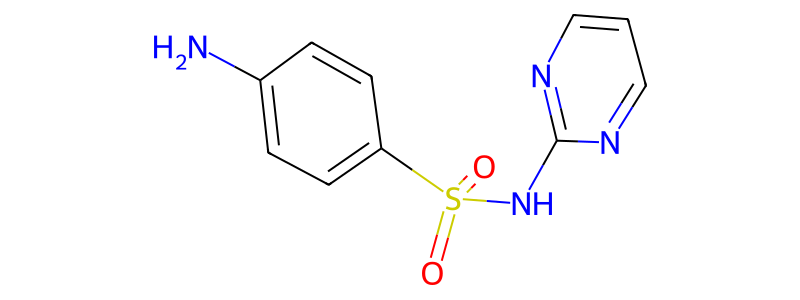

Above is molecule 115


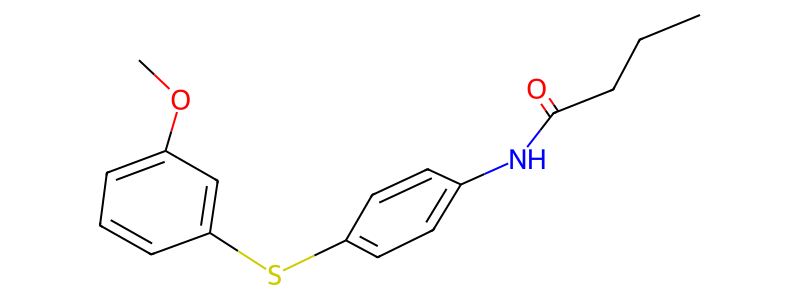

Above is molecule 116


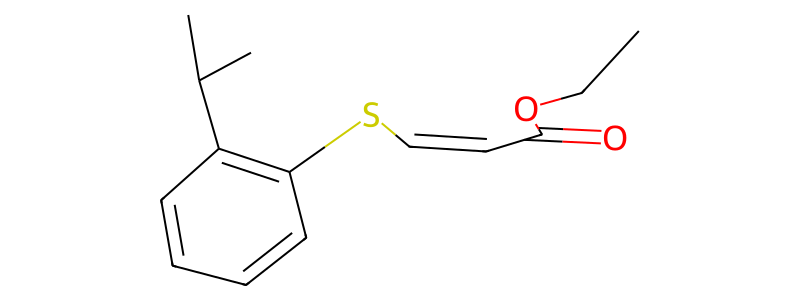

Above is molecule 117


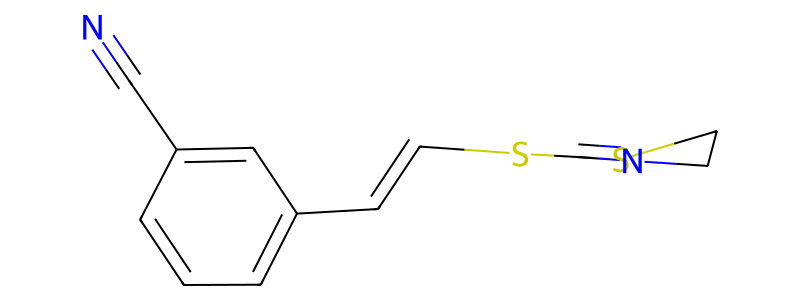

Above is molecule 118


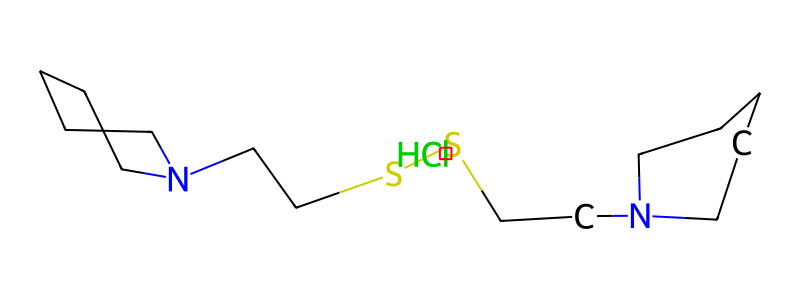

Above is molecule 119


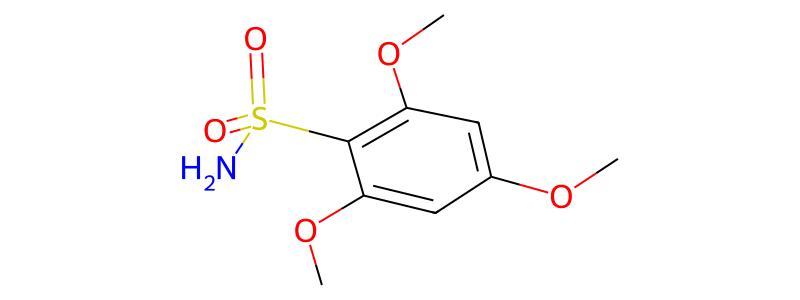

Above is molecule 120


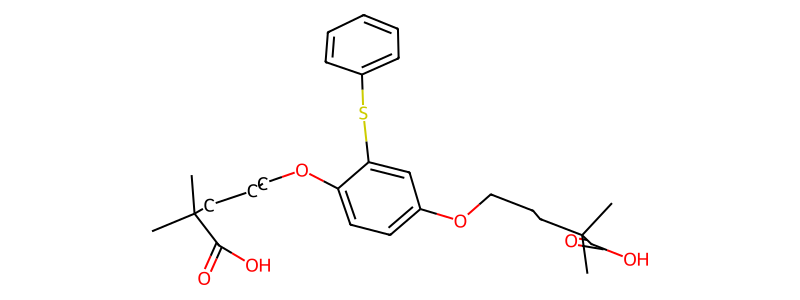

Above is molecule 121


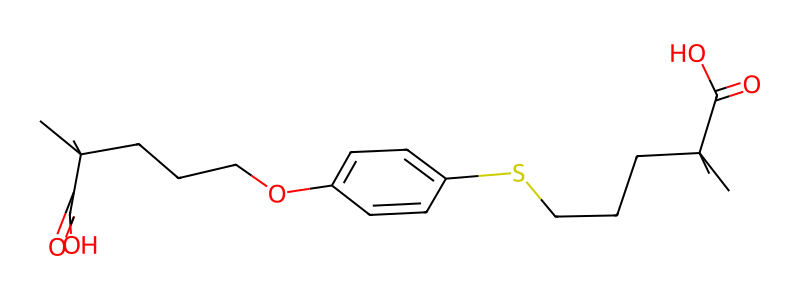

Above is molecule 122


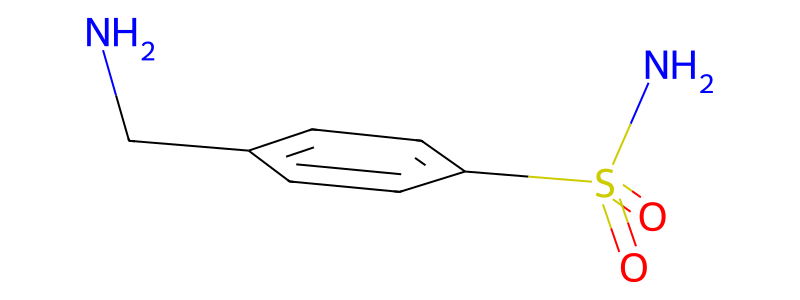

Above is molecule 123


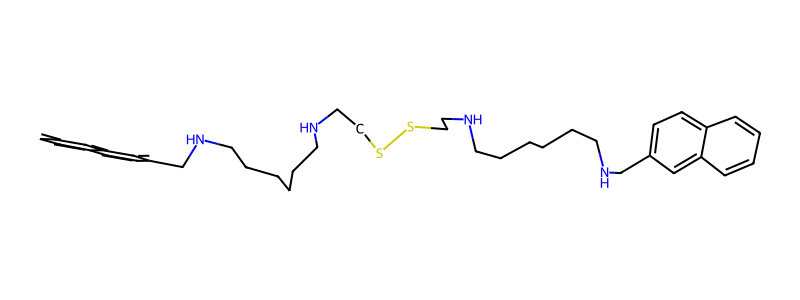

Above is molecule 124


In [ ]:
# Specify the range of SDF files to display (e.g., 1 to 123)
# This  way the molecules are generated 1 after another in a big list rather than a small column where you can't see them
start_idx = 1
end_idx = start_idx + 1

# List to store molecules for batch display
molecules = []

# Loop through the specified range of files
while start_idx < 124:
    for idx in range(start_idx, end_idx + 1):
        filename = f'molecule_{idx}.sdf'
        # Read the molecule from the SDF file
        suppl = Chem.SDMolSupplier(filename)
        # Get the first molecule from the file
        mol = suppl[0] 
        if mol:
            molecules = []
            molecules.append(mol)
            # Display molecules in a grid 
            if molecules:
                img = Draw.MolsToGridImage(molecules, molsPerRow=1, subImgSize=(800, 300))                  
                display(img)
                print("Above is molecule",start_idx)
                start_idx = start_idx + 1
                end_idx = start_idx + 1 
               
                
    
    


In [53]:
## THIS WILL CREATE MATRIX OF THE SIMILARITY IN THE SET OF Y

## IF the set of Y is TOO BIG, it will create a huge table! 

# I now want to check the tanimoto similarity WITHIN the set Y, to check that they aren't all different in the same way

'''
unique_fps = [fingerprint_list[i] for i in unique_positions]

# Makes empty matrix to store the Tanimoto similarity values and display them at the end
similarity_matrix = []

# Loop over each pair of unique fingerprints
for i, fp1 in enumerate(unique_fps):
    #Store similarities for the THIS row
    row = []  
    for j, fp2 in enumerate(unique_fps):
        similarity = DataStructs.TanimotoSimilarity(fp1, fp2)

        # Append the similarity to the row and round to 2dp
        row.append(round(similarity, 2))
    # Append the row to the matrix 
    similarity_matrix.append(row)  

# Output the Tanimoto similarity matrix
print("Tanimoto Similarity Matrix:")
for row in similarity_matrix:
    print(row)

    '''##Remove the 3 ' to get matrix

'\nunique_fps = [fingerprint_list[i] for i in unique_positions]\n\n# Makes empty matrix to store the Tanimoto similarity values and display them at the end\nsimilarity_matrix = []\n\n# Loop over each pair of unique fingerprints\nfor i, fp1 in enumerate(unique_fps):\n    #Store similarities for the THIS row\n    row = []  \n    for j, fp2 in enumerate(unique_fps):\n        similarity = DataStructs.TanimotoSimilarity(fp1, fp2)\n\n        # Append the similarity to the row and round to 2dp\n        row.append(round(similarity, 2))\n    # Append the row to the matrix \n    similarity_matrix.append(row)  \n\n# Output the Tanimoto similarity matrix\nprint("Tanimoto Similarity Matrix:")\nfor row in similarity_matrix:\n    print(row)\n\n    '

In [ ]:



##then use github and follow instructions,
## Go to bp1 (blue pebble) and then look into the autoenrich readme and follow the instructions to train impression on the data. 

## Also send Calvin some pages of the thesis 